## Carga de datos


In [1]:
from google.cloud import bigquery
project_id = "dhub-glovo"
client = bigquery.Client(project=project_id)

funnel_data = """
WITH raw_data AS (
    SELECT
        a.country_code, ci.city_code, a.applicant_id, a.rider_id,
        a.created_at, a.approved_at,
        DATE_TRUNC(DATE(a.created_at), ISOWEEK) AS week,
        a.workflow.workflow_name,
        UPPER(a.custom_non_pii_fields.utm.source) AS utm_source_raw,
        UPPER(a.custom_non_pii_fields.utm.medium) AS utm_medium_raw,
        t.tier, s.name AS stage_name, tr.to_state,
        tr.created_at AS transition_created_at
    FROM `fulfillment-dwh-production.curated_data_shared.applicants` AS a
    CROSS JOIN UNNEST(a.workflow.tiers)  AS t
    CROSS JOIN UNNEST(t.stage)           AS s
    CROSS JOIN UNNEST(s.transitions)     AS tr
    JOIN `fulfillment-dwh-production.curated_data_shared.countries` AS co ON co.country_code = a.country_code
    CROSS JOIN UNNEST(co.cities) AS ci ON a.city_id = ci.id
    WHERE a.country_code = 'gv-pl'
    AND DATE(a.created_at) >= DATE_TRUNC(DATE_SUB(CURRENT_DATE, INTERVAL 12 MONTH), MONTH)
    AND DATE(a.created_at) <= DATE_SUB(CURRENT_DATE, INTERVAL 30 DAY)
),

-- Mini query de diagnóstico embebida para ver doc_collection por workflow
doc_collection_check AS (
    SELECT
        r.workflow_name,
        r.applicant_id,
        -- "3PL already assigned": tier 0
        CASE WHEN r.workflow_name = '3PL already assigned leads PL'
                  AND r.tier = 0 AND r.stage_name = 'Document Collection' AND r.to_state = 'available'
             THEN r.transition_created_at END AS doc_col_start_3pl,
        CASE WHEN r.workflow_name = '3PL already assigned leads PL'
                  AND r.tier = 0 AND r.stage_name = 'Document Collection' AND r.to_state = 'completed'
             THEN r.transition_created_at END AS doc_col_end_3pl,
        -- "Other leads PL": tier 1
        CASE WHEN r.workflow_name = 'Other leads PL'
                  AND r.tier = 1 AND r.stage_name = 'Document Collection' AND r.to_state = 'available'
             THEN r.transition_created_at END AS doc_col_start_other,
        CASE WHEN r.workflow_name = 'Other leads PL'
                  AND r.tier = 1 AND r.stage_name = 'Document Collection' AND r.to_state = 'completed'
             THEN r.transition_created_at END AS doc_col_end_other
    FROM raw_data AS r
),

times_funnel_stages_raw AS (
    SELECT
        r.country_code, r.city_code, r.week, r.applicant_id, r.rider_id,
        r.created_at, r.approved_at, r.workflow_name,
        r.utm_source_raw, r.utm_medium_raw,

        -- T0 selección 3PL: solo "Other leads PL", tier 0
        CASE WHEN r.workflow_name = 'Other leads PL'
                  AND r.tier = 0 AND r.stage_name = 'Document Collection' AND r.to_state = 'available'
             THEN r.transition_created_at END AS pending_3pl_start,

        CASE WHEN r.workflow_name = 'Other leads PL'
                  AND r.tier = 0 AND r.stage_name = 'Document Collection' AND r.to_state = 'completed'
             THEN r.transition_created_at END AS pending_3pl_end,

        -- doc_collection: tier 1 para "Other leads PL", tier 0 para "3PL already assigned"
        CASE WHEN r.workflow_name = 'Other leads PL'
                  AND r.tier = 1 AND r.stage_name = 'Document Collection' AND r.to_state = 'available'
             THEN r.transition_created_at
             WHEN r.workflow_name LIKE '%3PL already assigned%'
                  AND r.tier = 0 AND r.stage_name = 'Document Collection' AND r.to_state = 'available'
             THEN r.transition_created_at END AS doc_collection_start,

        CASE WHEN r.workflow_name = 'Other leads PL'
                  AND r.tier = 1 AND r.stage_name = 'Document Collection' AND r.to_state = 'completed'
             THEN r.transition_created_at
             WHEN r.workflow_name LIKE '%3PL already assigned%'
                  AND r.tier = 0 AND r.stage_name = 'Document Collection' AND r.to_state = 'completed'
             THEN r.transition_created_at END AS doc_collection_end,

        -- Document Review
        CASE WHEN r.stage_name = 'Document Review' AND r.to_state = 'available'
             THEN r.transition_created_at END AS doc_review_start,
        CASE WHEN r.stage_name = 'Document Review' AND r.to_state = 'action_required'
             THEN r.transition_created_at END AS doc_nok_start,
        CASE WHEN r.stage_name = 'Document Review' AND r.to_state = 'completed'
             THEN r.transition_created_at END AS doc_review_end,

        -- Waiting List
        CASE WHEN r.stage_name = 'Waiting list' AND r.to_state = 'available'
             THEN r.transition_created_at END AS wl_start,
        CASE WHEN r.stage_name = 'Waiting list' AND r.to_state = 'completed'
             THEN r.transition_created_at END AS wl_end,

        -- Equipment Collection
        CASE WHEN r.stage_name = 'Equipment Collection' AND r.to_state = 'available'
             THEN r.transition_created_at END AS equip_collection_start,
        CASE WHEN r.stage_name = 'Equipment Collection' AND r.to_state = 'completed'
             THEN r.transition_created_at END AS equip_collection_end

    FROM raw_data AS r
),

times_funnel_stages AS (
    SELECT
        t.country_code, t.city_code, t.week, t.applicant_id, t.rider_id,
        t.created_at, t.approved_at, t.workflow_name,
        ANY_VALUE(t.utm_source_raw)   AS utm_source_raw,
        ANY_VALUE(t.utm_medium_raw)   AS utm_medium_raw,
        MAX(t.pending_3pl_start)      AS pending_3pl_start,
        MAX(t.pending_3pl_end)        AS pending_3pl_end,
        MAX(t.doc_collection_start)   AS doc_collection_start,
        MAX(t.doc_collection_end)     AS doc_collection_end,
        MAX(t.doc_review_start)       AS doc_review_start,
        MIN(t.doc_nok_start)          AS doc_nok_start,  -- MIN = primer NOK
        MAX(t.doc_review_end)         AS doc_review_end,
        MAX(t.wl_start)               AS wl_start,
        MAX(t.wl_end)                 AS wl_end,
        MAX(t.equip_collection_start) AS equip_collection_start,
        MAX(t.equip_collection_end)   AS equip_collection_end
    FROM times_funnel_stages_raw AS t
    GROUP BY 1,2,3,4,5,6,7,8
),

funnel_stages_difference AS (
    SELECT
        t.country_code, t.city_code, t.week, t.applicant_id, t.rider_id,
        t.workflow_name,
        CASE WHEN t.approved_at IS NOT NULL THEN 1 ELSE 0 END AS was_hired,

        -- lead_to_hired: NULL si no se contrató
        CASE WHEN t.approved_at IS NOT NULL
             THEN GREATEST((CAST(DATE_DIFF(t.approved_at, t.created_at, MINUTE) AS FLOAT64)/60)/24, 0)
        END AS lead_to_hired,

        -- pending_3pl_time: solo "Other leads PL", NULL para "3PL already assigned"
        CASE WHEN t.pending_3pl_start IS NOT NULL AND t.pending_3pl_end IS NOT NULL
             THEN GREATEST((CAST(DATE_DIFF(t.pending_3pl_end, t.pending_3pl_start, MINUTE) AS FLOAT64)/60)/24, 0)
        END AS pending_3pl_time,

        -- doc_collection_time: tiempo real subiendo docs (ambos workflows)
        CASE WHEN t.doc_collection_start IS NOT NULL AND t.doc_collection_end IS NOT NULL
             THEN GREATEST((CAST(DATE_DIFF(t.doc_collection_end, t.doc_collection_start, MINUTE) AS FLOAT64)/60)/24, 0)
        END AS doc_collection_time,

        -- doc_coll_to_doc_review: espera entre fin docs y inicio revisión
        CASE WHEN t.doc_collection_end IS NOT NULL AND t.doc_review_start IS NOT NULL
             THEN GREATEST((CAST(DATE_DIFF(t.doc_review_start, t.doc_collection_end, MINUTE) AS FLOAT64)/60)/24, 0)
        END AS doc_coll_to_doc_review,

        -- doc_review_time: tiempo total en revisión
        CASE WHEN t.doc_review_start IS NOT NULL AND t.doc_review_end IS NOT NULL
             THEN GREATEST((CAST(DATE_DIFF(t.doc_review_end, t.doc_review_start, MINUTE) AS FLOAT64)/60)/24, 0)
        END AS doc_review_time,

        -- had_doc_nok: flag binario
        CASE WHEN t.doc_nok_start IS NOT NULL THEN 1 ELSE 0 END AS had_doc_nok,

        -- doc_nok_correction_time: desde primer NOK hasta completed
        CASE WHEN t.doc_nok_start IS NOT NULL AND t.doc_review_end IS NOT NULL
             THEN GREATEST((CAST(DATE_DIFF(t.doc_review_end, t.doc_nok_start, MINUTE) AS FLOAT64)/60)/24, 0)
        END AS doc_nok_correction_time,

        -- wl_time: tiempo en waiting list
        CASE WHEN t.wl_start IS NOT NULL AND t.wl_end IS NOT NULL
             THEN GREATEST((CAST(DATE_DIFF(t.wl_end, t.wl_start, MINUTE) AS FLOAT64)/60)/24, 0)
        END AS wl_time,

        -- equip_time: tiempo en equipment collection
        CASE WHEN t.equip_collection_start IS NOT NULL AND t.equip_collection_end IS NOT NULL
             THEN GREATEST((CAST(DATE_DIFF(t.equip_collection_end, t.equip_collection_start, MINUTE) AS FLOAT64)/60)/24, 0)
        END AS equip_time,

        -- equip_to_hired: desde fin equipment hasta contratación
        CASE WHEN t.equip_collection_end IS NOT NULL AND t.approved_at IS NOT NULL
             THEN GREATEST((CAST(DATE_DIFF(t.approved_at, t.equip_collection_end, MINUTE) AS FLOAT64)/60)/24, 0)
        END AS equip_to_hired

    FROM times_funnel_stages AS t
),

target AS (
    SELECT
        a.applicant_id, a.rider_id,
        CASE WHEN ra.first_order_creation_datetime IS NOT NULL THEN 1 ELSE 0 END AS is_cfo
    FROM `fulfillment-dwh-production.curated_data_shared.applicants` AS a
    LEFT JOIN `fulfillment-dwh-production.curated_data_shared_glovo.rider_attributes__rider_attributes` AS ra
        ON ra.rider_id = a.rider_id
    WHERE a.country_code = 'gv-pl'
    AND DATE(a.created_at) >= DATE_TRUNC(DATE_SUB(CURRENT_DATE, INTERVAL 12 MONTH), MONTH)
    AND DATE(a.created_at) <= DATE_SUB(CURRENT_DATE, INTERVAL 30 DAY)
),

rider_profile AS (
    SELECT
        a.applicant_id, a.rider_id,
        a.rejection_category, a.rejection_type, a.current_stage_name,
        a.duplicate, a.company_name, a.created_at,
        (SELECT cf.value FROM UNNEST(a.custom_fields) AS cf WHERE cf.name = 'vehicle' LIMIT 1) AS vehicle_from_custom_fields,
        CASE
            WHEN UPPER(a.custom_non_pii_fields.utm.source) LIKE '%REFERRAL%'
              OR UPPER(a.custom_non_pii_fields.utm.source) LIKE '%RAF%'      THEN 'REFERRAL'
            WHEN UPPER(a.custom_non_pii_fields.utm.source) LIKE '%3PL%'      THEN '3PL'
            WHEN UPPER(a.custom_non_pii_fields.utm.source) LIKE '%RIDERHUB%' THEN 'RIDER WEB'
            WHEN UPPER(a.custom_non_pii_fields.utm.medium) LIKE '%JOBPLATFORM%' THEN 'JOB PLATFORM'
            WHEN (UPPER(a.custom_non_pii_fields.utm.source) LIKE '%GOOGLE%'
               OR UPPER(a.custom_non_pii_fields.utm.source) LIKE '%FACEBOOK%'
               OR UPPER(a.custom_non_pii_fields.utm.source) LIKE '%TIKTOK%')
             AND UPPER(a.custom_non_pii_fields.utm.medium) <> 'SOCIAL'       THEN 'PERF MKT'
            WHEN UPPER(a.custom_non_pii_fields.utm.medium) = 'OFFLINE'
             AND UPPER(a.custom_non_pii_fields.utm.source) NOT IN ('BRANDAMBASSADOR','CAPTAIN') THEN 'OFFLINE'
            WHEN UPPER(a.custom_non_pii_fields.utm.source) IN ('BRANDAMBASSADOR','CAPTAIN') THEN 'BRAND AMBASSADOR'
            WHEN UPPER(a.custom_non_pii_fields.utm.medium) = 'SOCIAL'        THEN 'SOCIAL MEDIA'
            ELSE 'ORGANIC'
        END AS source,
        CASE WHEN a.custom_non_pii_fields.registration_source = 'web' THEN 1
             WHEN a.custom_non_pii_fields.registration_source = 'app' THEN 0
             ELSE NULL END AS registered_via_web,
        CASE WHEN EXTRACT(MONTH FROM a.created_at) IN (12,1,2) THEN 'winter'
             WHEN EXTRACT(MONTH FROM a.created_at) IN (3,4,5)  THEN 'spring'
             WHEN EXTRACT(MONTH FROM a.created_at) IN (6,7,8)  THEN 'summer'
             ELSE 'autumn' END AS apply_season
    FROM `fulfillment-dwh-production.curated_data_shared.applicants` AS a
    WHERE a.country_code = 'gv-pl'
    AND DATE(a.created_at) >= DATE_TRUNC(DATE_SUB(CURRENT_DATE, INTERVAL 12 MONTH), MONTH)
    AND DATE(a.created_at) <= DATE_SUB(CURRENT_DATE, INTERVAL 30 DAY)
),

rider_attributes AS (
    SELECT ra.rider_id, ra.vehicle_type, ra.business_model, ra.is_3pl
    FROM `fulfillment-dwh-production.curated_data_shared_glovo.rider_attributes__rider_attributes` AS ra
    WHERE ra.country_code = 'PL'
),

-- Diagnóstico: verificar captura de doc_collection por workflow
diag_doc_collection AS (
    SELECT
        t.workflow_name,
        COUNT(*) AS n,
        COUNTIF(t.doc_collection_start IS NOT NULL) AS con_doc_collection_start,
        COUNTIF(t.doc_collection_end IS NOT NULL)   AS con_doc_collection_end
    FROM times_funnel_stages AS t
    GROUP BY t.workflow_name
)

SELECT
    d.applicant_id,
    d.city_code,
    rp.created_at,
    DATE_TRUNC(d.week, MONTH)           AS month,
    d.rider_id,
    d.workflow_name,

    -- Target y flags
    t.is_cfo,
    d.was_hired,
    d.had_doc_nok,

    -- Perfil del lead
    rp.rejection_category,
    rp.rejection_type,
    rp.current_stage_name,
    rp.company_name,
    rp.vehicle_from_custom_fields,
    ra.vehicle_type,
    ra.business_model,
    ra.is_3pl,
    rp.source,
    rp.registered_via_web,
    rp.apply_season,
    rp.duplicate,

    -- Tiempos del funnel
    d.lead_to_hired,
    d.pending_3pl_time,
    d.doc_collection_time,
    d.doc_coll_to_doc_review,
    d.doc_review_time,
    d.doc_nok_correction_time,
    d.wl_time,
    d.equip_time,
    d.equip_to_hired

FROM funnel_stages_difference AS d
LEFT JOIN target           AS t  ON d.applicant_id = t.applicant_id
LEFT JOIN rider_profile    AS rp ON d.applicant_id = rp.applicant_id
LEFT JOIN rider_attributes AS ra ON d.rider_id     = ra.rider_id
WHERE d.city_code IS NOT NULL
"""

df = client.query(funnel_data).to_dataframe()
print(f'Filas: {len(df):,}  Columnas: {df.shape[1]}')
print(f'CFO rate: {df["is_cfo"].mean():.2%}')
print(f'was_hired rate: {df["was_hired"].mean():.2%}')
print(f'\nNulls por columna:')
print(df.isna().sum()[df.isna().sum() > 0])

c:\Users\PabloGimeno\AppData\Local\Programs\Python\Python39\lib\site-packages\google\api_core\_python_version_support.py:246: FutureWarning: You are using a non-supported Python version (3.9.13). Google will not post any further updates to google.api_core supporting this Python version. Please upgrade to the latest Python version, or at least Python 3.10, and then update google.api_core.
  warnings.warn(message, FutureWarning)
c:\Users\PabloGimeno\AppData\Local\Programs\Python\Python39\lib\site-packages\google\auth\__init__.py:54: FutureWarning: You are using a Python version 3.9 past its end of life. Google will update google-auth with critical bug fixes on a best-effort basis, but not with any other fixes or features. Please upgrade your Python version, and then update google-auth.
  warnings.warn(eol_message.format("3.9"), FutureWarning)
c:\Users\PabloGimeno\AppData\Local\Programs\Python\Python39\lib\site-packages\google\oauth2\__init__.py:40: FutureWarning: You are using a Python v

Filas: 164,527  Columnas: 30
CFO rate: 23.36%
was_hired rate: 40.74%

Nulls por columna:
rider_id                      101961
rejection_category             78471
rejection_type                 78471
current_stage_name                 1
company_name                   24225
vehicle_from_custom_fields        58
vehicle_type                  102073
business_model                102073
is_3pl                        102073
registered_via_web                60
lead_to_hired                  97502
pending_3pl_time               79209
doc_collection_time            64416
doc_coll_to_doc_review         64416
doc_review_time                84992
doc_nok_correction_time       141331
wl_time                        86573
equip_time                     94010
equip_to_hired                 97502
dtype: int64


In [2]:
df.to_csv('data_funnel.csv', index=False)

## Carga de Librerías Necesarias


In [3]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import re, json, os, joblib
import shap
import optuna
import warnings
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

from sklearn.metrics import (
    roc_auc_score, average_precision_score, classification_report,
    confusion_matrix, roc_curve, precision_recall_curve,
    f1_score, brier_score_loss, log_loss
)
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.model_selection import StratifiedKFold, train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
print(f'LightGBM version: {lgb.__version__}')

# Color palette
COLORS = {
    'primary': '#1a73e8',
    'secondary': '#e8710a',
    'success': '#2ecc71',
    'danger': '#e74c3c',
    'gray': '#95a5a6',
    'dark': '#2c3e50',
    'palette': ['#1a73e8', '#e8710a', '#2ecc71', '#e74c3c', '#9b59b6', '#1abc9c', '#f39c12', '#34495e']
}


c:\Users\PabloGimeno\AppData\Local\Programs\Python\Python39\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


LightGBM version: 4.6.0


## Lectura y Exploración Inicial de los Datos


In [4]:
df = pd.read_csv('data_funnel.csv', parse_dates=['month'])


In [5]:
print(f'Filas: {len(df):,}  Columnas: {df.shape[1]}')
print(f'Tasa de conversión a CFO: {df["is_cfo"].mean():.2%}')
print(f'\nNulls por columna:')
# Crear la tabla de resumen en un solo paso
resumen = pd.concat([
    df.isnull().sum(), 
    (df.isnull().sum() / len(df)) * 100, 
    df.dtypes
], axis=1)

# Renombrar columnas para que sea legible
resumen.columns = ['Nulos', '% Nulos', 'Tipo']

print(resumen)

Filas: 164,527  Columnas: 30
Tasa de conversión a CFO: 23.36%

Nulls por columna:
                             Nulos    % Nulos            Tipo
applicant_id                     0   0.000000          object
city_code                        0   0.000000          object
created_at                       0   0.000000          object
month                            0   0.000000  datetime64[ns]
rider_id                    101961  61.972199         float64
workflow_name                    0   0.000000          object
is_cfo                           0   0.000000           int64
was_hired                        0   0.000000           int64
had_doc_nok                      0   0.000000           int64
rejection_category           78471  47.694907          object
rejection_type               78471  47.694907          object
current_stage_name               1   0.000608          object
company_name                 24225  14.724027          object
vehicle_from_custom_fields      58   0.035253     

In [6]:
# 1. Contar cuántas filas son duplicados exactos
total_duplicados = df.duplicated().sum()
print(f"Filas duplicadas detectadas: {total_duplicados}")

# 2. Eliminar duplicados y guardar en un nuevo df (o en el mismo)
# keep='first' mantiene la primera aparición y borra las repetidas
df_clean = df.drop_duplicates(keep='first')

# 3. Verificar el nuevo tamaño
print(f"Tamaño original: {len(df)}")
print(f"Tamaño tras limpieza: {len(df_clean)}")


Filas duplicadas detectadas: 0
Tamaño original: 164527
Tamaño tras limpieza: 164527


In [7]:
print(df.shape)
print(df.columns)


(164527, 30)
Index(['applicant_id', 'city_code', 'created_at', 'month', 'rider_id',
       'workflow_name', 'is_cfo', 'was_hired', 'had_doc_nok',
       'rejection_category', 'rejection_type', 'current_stage_name',
       'company_name', 'vehicle_from_custom_fields', 'vehicle_type',
       'business_model', 'is_3pl', 'source', 'registered_via_web',
       'apply_season', 'duplicate', 'lead_to_hired', 'pending_3pl_time',
       'doc_collection_time', 'doc_coll_to_doc_review', 'doc_review_time',
       'doc_nok_correction_time', 'wl_time', 'equip_time', 'equip_to_hired'],
      dtype='object')


In [8]:
df.head()

,applicant_id,city_code,created_at,month,rider_id,workflow_name,is_cfo,was_hired,had_doc_nok,rejection_category,...,duplicate,lead_to_hired,pending_3pl_time,doc_collection_time,doc_coll_to_doc_review,doc_review_time,doc_nok_correction_time,wl_time,equip_time,equip_to_hired
0,13837127-2360-4e5a-a52b-4944fece2386,WAW,2026-02-23 10:10:33.606761+00:00,2026-02-01,NaN,3PL already assigned leads PL\t,0,0,0,NaN,...,False,NaN,NaN,0.001389,0.0,0.000000,NaN,1.031944,0.0,NaN
1,61b80e3e-2694-4ce8-9ae4-03773c3ddc17,POZ,2026-02-25 11:31:05.862885+00:00,2026-02-01,NaN,3PL already assigned leads PL\t,0,0,0,NaN,...,False,NaN,NaN,0.000000,0.0,0.887500,NaN,5.055556,0.0,NaN
2,dc679c15-5d82-42fa-a0d9-1a3803615564,POZ,2026-02-26 23:47:20.673337+00:00,2026-02-01,NaN,3PL already assigned leads PL\t,0,0,0,NaN,...,False,NaN,NaN,0.000000,0.0,0.361111,NaN,4.070139,0.0,NaN
3,28ef2da4-0d71-48fa-a7b8-818760f7854b,LEZ,2026-02-20 14:13:27.527649+00:00,2026-02-01,NaN,Other leads PL,0,0,1,NaN,...,False,NaN,0.000694,0.002778,0.0,41.847222,41.116667,NaN,NaN,NaN
4,fcd7a9f2-8941-40a3-9253-781b803ddd71,TCH,2026-02-06 17:28:25.985418+00:00,2026-02-01,NaN,Other leads PL,0,0,1,NaN,...,False,NaN,0.000000,0.002083,0.0,2.681250,2.676389,NaN,NaN,NaN


In [9]:
df["vehicle_from_custom_fields"].unique()


array(['qhtpqMSFukJ4LDE6VTl89O9cPVRAOmxYs3opl6+zPOA=',
       'cvP/h4q0DgErp8L9/Vsls0yQSg/aOCaf6uLmBpCnbRI=',
       '0pr4ouFg3YZ/5Fp19wv4BbG2wc+SAXz1PN8dXPOQyRY=',
       'KylhpDGyPJAH7+JwwdfrecGdQZLXzS2SQXbrCxnn0qE=',
       'ygogrc956kh2b9//SdQoapHkpff9mZUlCIWHTK9zciw=',
       'xIgVqIq+GLIvncTQTeHXaZIlK/7+ZW6yjg1q/MmWv58=', nan,
       'ta0SEwe5xIZHHR0uRbvPpwzzESXiBJxm9li89AAWyE4=',
       'FjwY4AaPCln9yma2oiJTolKkE5ZuM7NaDkXdo8Wt01E=',
       '4U3qHu7O4ReEwkomKjA6UUzTgNpOc1MEPAmrbpuepD0=',
       'LloZlAYNX9u900zV9qHo4ircDJAcKaR7+WhwlEGu0xk=',
       'sx5GswQ3LbGcaIjRXL+XIJwoo1SmBhUDNRu0TKrvHdU=',
       '0Qp2imvhLsnmgOC2oKreU6m3R0zBieBQ+l3X7uMHd7I=',
       'xORDA33uM4MzCQ/qSizOwLMK0Tyboh1QAqhKTmYdHJM=',
       'UkOL7ZNZMT6MjGTAJfqhDCAf0djh2qGfUkm7KcxlqA8=',
       'iMGs5qAdY1esDHH2NOAaJlxjSH3COVjEN7EZ7ULb+Nk=',
       'rF2pKU8MVzM8f8rdQTLp5hNdO3aVA3iOVVEDOA3wWRc=',
       '/Z0PNsoC01lXHrwka610p9pNWdugaU5qJi2npnzWZ1c=',
       'pc3wfbvBWJLctk8VU+u0dDMDk3Bc5HCyLwGU9YIjQ3E=',
     

In [10]:
#Vehicle Formatting

df["vehicle_from_custom_fields"].unique()


mapa = {
    # BICICLETAS
    'bicycle': 'bicycle', 
    'Bicycle': 'bicycle', 
    'bike': 'bicycle', 
    'Bike': 'bicycle', 
    'Ebicycle': 'bicycle', 
    'rower': 'bicycle',
    
    # ELECTRIC BICYCLE
    'electric bicycle': 'electric bicycle', 
    'electric bicycle ': 'electric bicycle',
    'Electric bicycle': 'electric bicycle', 
    'Electric Bicycle': 'electric bicycle',
    'electric bike': 'electric bicycle', 
    'Electric bike': 'electric bicycle',
    'electric bicykle': 'electric bicycle', 
    'bicycle electric': 'electric bicycle',
    'elektric bicycle': 'electric bicycle',
    'ebicycle': 'electric bicycle',

    
    # CAR
    'car': 'car', 
    'Car': 'car', 
    'samochód': 'car',
    
    # MOTORBIKE
    'motorbike': 'motorbike', 
    'motorbike ': 'motorbike', 
    'Motorbike': 'motorbike',
    'notorbike': 'motorbike', 
    'motobike': 'motorbike',
    
    # ELECTRIC MOTORBIKE
    'electric motorbike': 'electric motorbike',
    
    # ELECTRIC CAR
    'electric car': 'electric car',
    
    # OTROS (Hui y Scooter)
    'Hui': 'others', 
    'scooter': 'others',
    'electric car': 'others'
}

# Aplicamos el mapeo. Las que no estén en el diccionario se quedan igual.
df['vehicle'] = df['vehicle_from_custom_fields'].replace(mapa)

print(df['vehicle'].value_counts())

vehicle
KylhpDGyPJAH7+JwwdfrecGdQZLXzS2SQXbrCxnn0qE=    70418
0pr4ouFg3YZ/5Fp19wv4BbG2wc+SAXz1PN8dXPOQyRY=    52315
cvP/h4q0DgErp8L9/Vsls0yQSg/aOCaf6uLmBpCnbRI=    22967
qhtpqMSFukJ4LDE6VTl89O9cPVRAOmxYs3opl6+zPOA=    13217
ygogrc956kh2b9//SdQoapHkpff9mZUlCIWHTK9zciw=     5512
4U3qHu7O4ReEwkomKjA6UUzTgNpOc1MEPAmrbpuepD0=        7
LloZlAYNX9u900zV9qHo4ircDJAcKaR7+WhwlEGu0xk=        6
0Qp2imvhLsnmgOC2oKreU6m3R0zBieBQ+l3X7uMHd7I=        4
pc3wfbvBWJLctk8VU+u0dDMDk3Bc5HCyLwGU9YIjQ3E=        4
zHu3bV9nMPBdYGBOUb4NCea2r8GgbXMtjazd7R2MDjo=        2
riINnNZrnvMJYtKEtzJGAHxuxDgPCJu3YRqjYLVbfkc=        2
DVE655ZQBIpaRTT5Fl7jeJhfTpBWuNI3NFf3YqBTbKs=        2
UkOL7ZNZMT6MjGTAJfqhDCAf0djh2qGfUkm7KcxlqA8=        2
FjwY4AaPCln9yma2oiJTolKkE5ZuM7NaDkXdo8Wt01E=        1
xIgVqIq+GLIvncTQTeHXaZIlK/7+ZW6yjg1q/MmWv58=        1
ta0SEwe5xIZHHR0uRbvPpwzzESXiBJxm9li89AAWyE4=        1
rF2pKU8MVzM8f8rdQTLp5hNdO3aVA3iOVVEDOA3wWRc=        1
iMGs5qAdY1esDHH2NOAaJlxjSH3COVjEN7EZ7ULb+Nk=        1
xORDA33uM4MzCQ/qSizO

In [11]:
# Month analysis: La migración de PL se realizo en marzo del 2025. Excluimos los meses anteriores para no sesgar los datos

leads_mensuales = df.groupby('month').agg(
    total_leads=('applicant_id', 'count')
).sort_index()

leads_mensuales

,total_leads
month,
2025-03-01,2053
2025-04-01,9991
2025-05-01,14320
2025-06-01,22592
2025-07-01,14522
2025-08-01,12878
2025-09-01,21073
2025-10-01,14951
2025-11-01,13323


In [12]:
df = df[df['month'] >= '2025-03-01'].copy()

In [13]:
#Time cols

nombres_nuevos = {
    'pending_3pl_time': 'Pending 3PL',
    'doc_collection_time': 'Document Collection',
    'doc_coll_to_doc_review': 'Doc Coll → Review',
    'doc_review_time': 'Document Review',
    'doc_nok_correction_time': 'Docs NoK Correction',
    'wl_time': 'Waiting List',
    'equip_time': 'Equipment Collection',
    'equip_to_hired': 'Equip → Hired',
    'lead_to_hired': 'Lead to ONB'
}

# Aplicamos el cambio al DataFrame
df = df.rename(columns=nombres_nuevos)

# Lista de columnas de tiempo para análisis (solo fases reales del funnel PL)
time_cols = [
    'Pending 3PL', 'Document Collection', 'Document Review',
    'Waiting List', 'Equipment Collection', 'Lead to ONB'
]

In [14]:
# 1. Aseguramos que la columna 'month' sea tipo datetime (si no lo es ya)
df['month'] = pd.to_datetime(df['month'])

# 2. Extraemos el año en una columna temporal para agrupar
df['year'] = df['month'].dt.year

# 3. Calculamos el rango de años
year_min = df['year'].min()
year_max = df['year'].max()
total_years = year_max - year_min + 1

print(f"--- RANGO TEMPORAL ---")
print(f"El dataset abarca desde {year_min} hasta {year_max} ({total_years} año(s) en total).")
print("-" * 30)

# 4. Contamos la información de leads por año
leads_por_año = df.groupby('year').agg(
    Total_Leads=('applicant_id', 'count'),
    Hired_Total=('was_hired', 'sum'),
    Tasa_Conversion_Hired=('was_hired', 'mean')
)

# Formateamos la tasa de conversión a porcentaje para que sea legible
leads_por_año['Tasa_Conversion_Hired'] = (leads_por_año['Tasa_Conversion_Hired'] * 100).round(2).astype(str) + '%'

print("--- INFORMACIÓN DE LEADS POR AÑO ---")
print(leads_por_año)

# (Opcional) Limpiamos la columna temporal si no la necesitas más
# df.drop(columns=['year'], inplace=True)

--- RANGO TEMPORAL ---
El dataset abarca desde 2025 hasta 2026 (2 año(s) en total).
------------------------------
--- INFORMACIÓN DE LEADS POR AÑO ---
      Total_Leads  Hired_Total Tasa_Conversion_Hired
year                                                
2025       136917        58486                42.72%
2026        27610         8539                30.93%


In [15]:
import pandas as pd
import numpy as np

# 1. Tu agrupación original
monthly = df.groupby('month').agg(
    leads=('applicant_id', 'count'),
    onboarded=('was_hired', 'sum'),
    cfo=('is_cfo', 'sum')
).sort_index()

# 2. Calculamos la fila de Total (solo para las columnas de conteo/suma)
total_row = pd.DataFrame({
    'leads': [monthly['leads'].sum()],
    'onboarded': [monthly['onboarded'].sum()],
    'cfo': [monthly['cfo'].sum()]
}, index=['Total'])

# 3. Concatenamos la fila de total al dataframe original
monthly = pd.concat([monthly, total_row])

# 4. Calculamos los ratios (esto aplicará tanto a los meses como a la fila Total)
monthly['lead_to_onb'] = (monthly['onboarded'] / monthly['leads'] * 100).round(1)
monthly['onb_to_cfo'] = (monthly['cfo'] / monthly['onboarded'].replace(0, np.nan) * 100).round(1)
monthly['lead_to_cfo'] = (monthly['cfo'] / monthly['leads'].replace(0, np.nan) * 100).round(1)

print("Evolución mensual con Totales:")
print(monthly.to_string())

Evolución mensual con Totales:
                      leads  onboarded    cfo  lead_to_onb  onb_to_cfo  lead_to_cfo
2025-03-01 00:00:00    2053        947    460         46.1        48.6         22.4
2025-04-01 00:00:00    9991       4997   2685         50.0        53.7         26.9
2025-05-01 00:00:00   14320       6942   3811         48.5        54.9         26.6
2025-06-01 00:00:00   22592       9373   5453         41.5        58.2         24.1
2025-07-01 00:00:00   14522       5879   3124         40.5        53.1         21.5
2025-08-01 00:00:00   12878       5054   2839         39.2        56.2         22.0
2025-09-01 00:00:00   21073       8161   5039         38.7        61.7         23.9
2025-10-01 00:00:00   14951       6581   3775         44.0        57.4         25.2
2025-11-01 00:00:00   13323       5730   3628         43.0        63.3         27.2
2025-12-01 00:00:00   11214       4822   2845         43.0        59.0         25.4
2026-01-01 00:00:00   12120       4770   2778

## 1. Overview del funnel: volúmenes y conversiones

Vista general mensual de leads, onboarded y CFO con sus tasas de conversión.


In [16]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

monthly = monthly.drop('Total', errors='ignore')
monthly.index = pd.to_datetime(monthly.index)
labels = monthly.index.strftime('%b %Y')

fig = make_subplots(
    rows=2, cols=1,
    row_heights=[0.65, 0.35],
    subplot_titles=['Volumen mensual: Leads → Onboarded → CFO', 'Tasas de conversión mensuales'],
    vertical_spacing=0.15
)

# Chart 1: Volúmenes (barras agrupadas)
fig.add_trace(go.Bar(
    x=labels, y=monthly['leads'], name='Leads',
    marker_color=COLORS['primary'], opacity=0.85,
    text=monthly['leads'].astype(int), textposition='outside', textfont_size=8
), row=1, col=1)

fig.add_trace(go.Bar(
    x=labels, y=monthly['onboarded'], name='Onboarded',
    marker_color=COLORS['success'], opacity=0.85
), row=1, col=1)

fig.add_trace(go.Bar(
    x=labels, y=monthly['cfo'], name='CFO',
    marker_color=COLORS['secondary'], opacity=0.85
), row=1, col=1)

# Chart 2: Tasas de conversión (líneas)
fig.add_trace(go.Scatter(
    x=labels, y=monthly['lead_to_onb'], name='lead_to_onb %',
    mode='lines+markers', marker=dict(symbol='circle', size=8),
    line=dict(color=COLORS['secondary'], width=2)
), row=2, col=1)

fig.add_trace(go.Scatter(
    x=labels, y=monthly['onb_to_cfo'], name='onb_to_cfo %',
    mode='lines+markers', marker=dict(symbol='triangle-up', size=8),
    line=dict(color=COLORS['success'], width=2, dash='dash')
), row=2, col=1)

# Layout
fig.update_layout(
    barmode='group',
    height=600, width=900,
    template='plotly_white',
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='center', x=0.5)
)

fig.update_yaxes(title_text='Número de leads', row=1, col=1)
fig.update_yaxes(title_text='%', ticksuffix='%', row=2, col=1)
fig.update_xaxes(tickangle=45, row=1, col=1)
fig.update_xaxes(tickangle=45, row=2, col=1)

fig.show()

## 2. Análisis de rechazos

Entender los motivos de rechazo, su frecuencia y si ciertos perfiles tienen más rechazos.


In [17]:
# Rechazos generales
df_rejected = df[df['rejection_category'].notna()].copy()
print(f"Total leads con rechazo: {len(df_rejected):,} ({len(df_rejected)/len(df)*100:.1f}% del total)")
print()

# Por categoría
rej_cat = df_rejected['rejection_category'].value_counts()
print("Rechazos por categoría:")
print(rej_cat.to_string())
print()

# Por tipo (top 15)
rej_type = df_rejected['rejection_type'].value_counts().head(15)
print("Top 15 tipos de rechazo:")
print(rej_type.to_string())


Total leads con rechazo: 86,056 (52.3% del total)

Rechazos por categoría:
rejection_category
candidate_withdrawn    73270
recruiter_rejected     12786

Top 15 tipos de rechazo:
rejection_type
no_interest                43028
unresponsive               30224
duplicate                   6509
fraud                       4778
blacklisted                  740
not_old_enough               537
spam                         148
work_permit_missing           63
not_a_good_fit                18
missing_hardware               5
not_hiring_atm                 5
not_hiring_vehicle_type        1


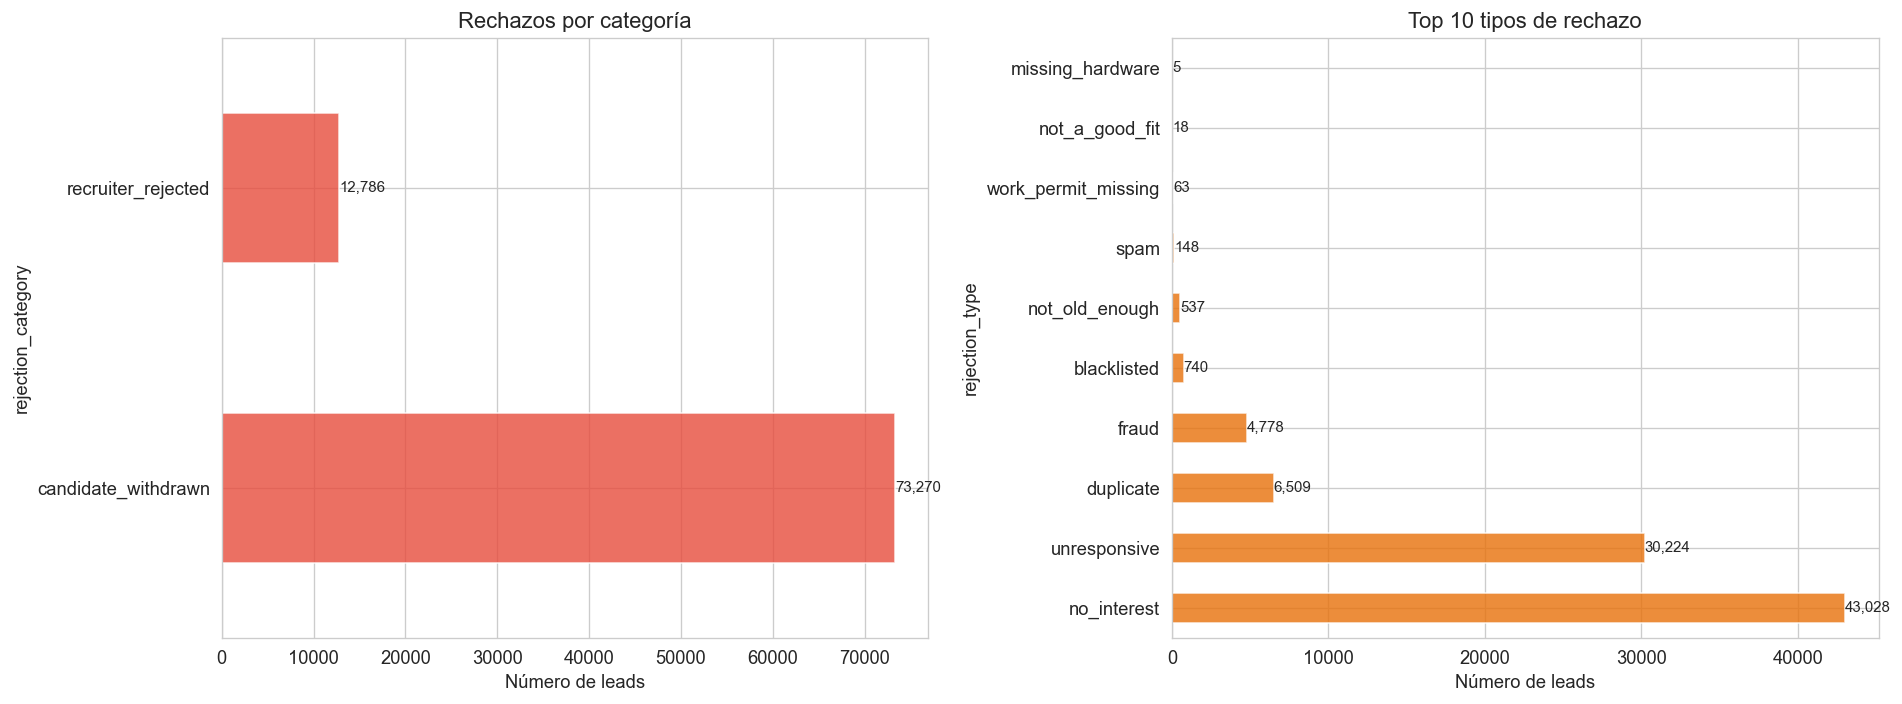

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Categoría
rej_cat.plot.barh(ax=axes[0], color=COLORS['danger'], alpha=0.8, edgecolor='white')
axes[0].set_title('Rechazos por categoría')
axes[0].set_xlabel('Número de leads')
for i, v in enumerate(rej_cat.values):
    axes[0].text(v + 5, i, f'{v:,}', va='center', fontsize=9)

# Tipo (top 10)
rej_type.head(10).plot.barh(ax=axes[1], color=COLORS['secondary'], alpha=0.8, edgecolor='white')
axes[1].set_title('Top 10 tipos de rechazo')
axes[1].set_xlabel('Número de leads')
for i, v in enumerate(rej_type.head(10).values):
    axes[1].text(v + 5, i, f'{v:,}', va='center', fontsize=9)

plt.tight_layout()
plt.show()


## 3. Drivers de conversión: segmentación por variables cualitativas

Análisis de lead_to_onb y onb_to_cfo por cada variable cualitativa, con gráficos comparativos.


In [19]:
def analyze_variable(df, var, filter_year=None):
    """Analiza conversión por variable cualitativa con tabla y gráfico."""
    df_work = df.copy()
    note = ""
    if filter_year:
        df_work = df_work[df_work['month'].dt.year == filter_year]
        note = f" [Solo {filter_year}]"
    
    analisis = df_work.groupby(var).agg(
        total_leads=('applicant_id', 'count'),
        onboarded=('was_hired', 'sum'),
        cfo=('is_cfo', 'sum')
    ).sort_values('total_leads', ascending=False)
    
    analisis['lead_to_onb'] = (analisis['onboarded'] / analisis['total_leads'] * 100).round(1)
    analisis['onb_to_cfo'] = (analisis['cfo'] / analisis['onboarded'].replace(0, np.nan) * 100).round(1)
    
    # Totales
    total = pd.DataFrame({
        'total_leads': analisis['total_leads'].sum(),
        'onboarded': analisis['onboarded'].sum(),
        'cfo': analisis['cfo'].sum(),
        'lead_to_onb': (analisis['onboarded'].sum() / analisis['total_leads'].sum() * 100).round(1),
        'onb_to_cfo': (analisis['cfo'].sum() / analisis['onboarded'].sum() * 100).round(1)
    }, index=['TOTAL'])
    
    result = pd.concat([analisis, total])
    
    print(f"\n{'='*70}")
    print(f">> {var.upper()}{note}")
    print(f"{'='*70}")
    print(result.to_string())
    
    # Gráfico
    plot_data = analisis[analisis['total_leads'] >= 30]  # Filtrar categorías con pocos datos
    if len(plot_data) > 1:
        fig, axes = plt.subplots(1, 3, figsize=(16, 4))
        
        plot_data['lead_to_onb'].sort_values().plot.barh(
            ax=axes[0], color=COLORS['primary'], alpha=0.8, edgecolor='white')
        axes[0].set_title(f'lead_to_onb by {var}')
        axes[0].set_xlabel('%')
        axes[0].axvline(analisis['lead_to_onb'].mean(), color='red', linestyle='--', alpha=0.5, label='avg')
        
        plot_data['onb_to_cfo'].sort_values().plot.barh(
            ax=axes[1], color=COLORS['secondary'], alpha=0.8, edgecolor='white')
        axes[1].set_title(f'onb_to_cfo by {var}')
        axes[1].set_xlabel('%')
        axes[1].axvline(analisis['onb_to_cfo'].mean(), color='red', linestyle='--', alpha=0.5, label='avg')
        
        plot_data['total_leads'].sort_values().plot.barh(
            ax=axes[2], color=COLORS['gray'], alpha=0.8, edgecolor='white')
        axes[2].set_title(f'Volume by {var}')
        axes[2].set_xlabel('Leads')
        
        plt.suptitle(f'Análisis por {var.upper()}{note}', fontsize=14, y=1.02)
        plt.tight_layout()
        plt.show()
    
    return result



>> SOURCE
              total_leads  onboarded    cfo  lead_to_onb  onb_to_cfo
ORGANIC             68697      25612  14802         37.3        57.8
3PL                 41304      22716  12886         55.0        56.7
PERF MKT            22590       6152   3299         27.2        53.6
JOB PLATFORM        15506       3706   1399         23.9        37.7
REFERRAL            13432       7980   5656         59.4        70.9
RIDER WEB            2998        859    398         28.7        46.3
TOTAL              164527      67025  38440         40.7        57.4


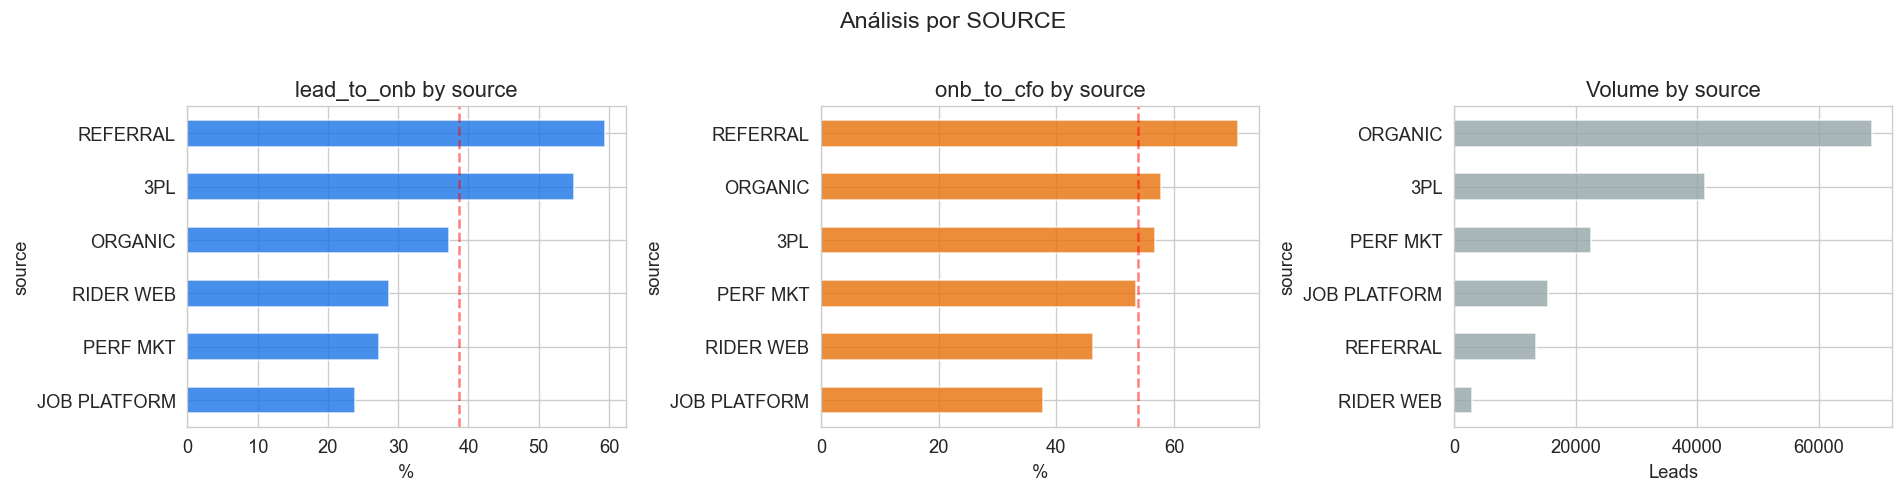


>> VEHICLE
                                              total_leads  onboarded    cfo  lead_to_onb  onb_to_cfo
KylhpDGyPJAH7+JwwdfrecGdQZLXzS2SQXbrCxnn0qE=        70418      27314  15631         38.8        57.2
0pr4ouFg3YZ/5Fp19wv4BbG2wc+SAXz1PN8dXPOQyRY=        52315      18425   9308         35.2        50.5
cvP/h4q0DgErp8L9/Vsls0yQSg/aOCaf6uLmBpCnbRI=        22967      11481   6777         50.0        59.0
qhtpqMSFukJ4LDE6VTl89O9cPVRAOmxYs3opl6+zPOA=        13217       6872   4611         52.0        67.1
ygogrc956kh2b9//SdQoapHkpff9mZUlCIWHTK9zciw=         5512       2872   2081         52.1        72.5
4U3qHu7O4ReEwkomKjA6UUzTgNpOc1MEPAmrbpuepD0=            7          1      0         14.3         0.0
LloZlAYNX9u900zV9qHo4ircDJAcKaR7+WhwlEGu0xk=            6          3      3         50.0       100.0
0Qp2imvhLsnmgOC2oKreU6m3R0zBieBQ+l3X7uMHd7I=            4          0      0          0.0         NaN
pc3wfbvBWJLctk8VU+u0dDMDk3Bc5HCyLwGU9YIjQ3E=            4          2      1    

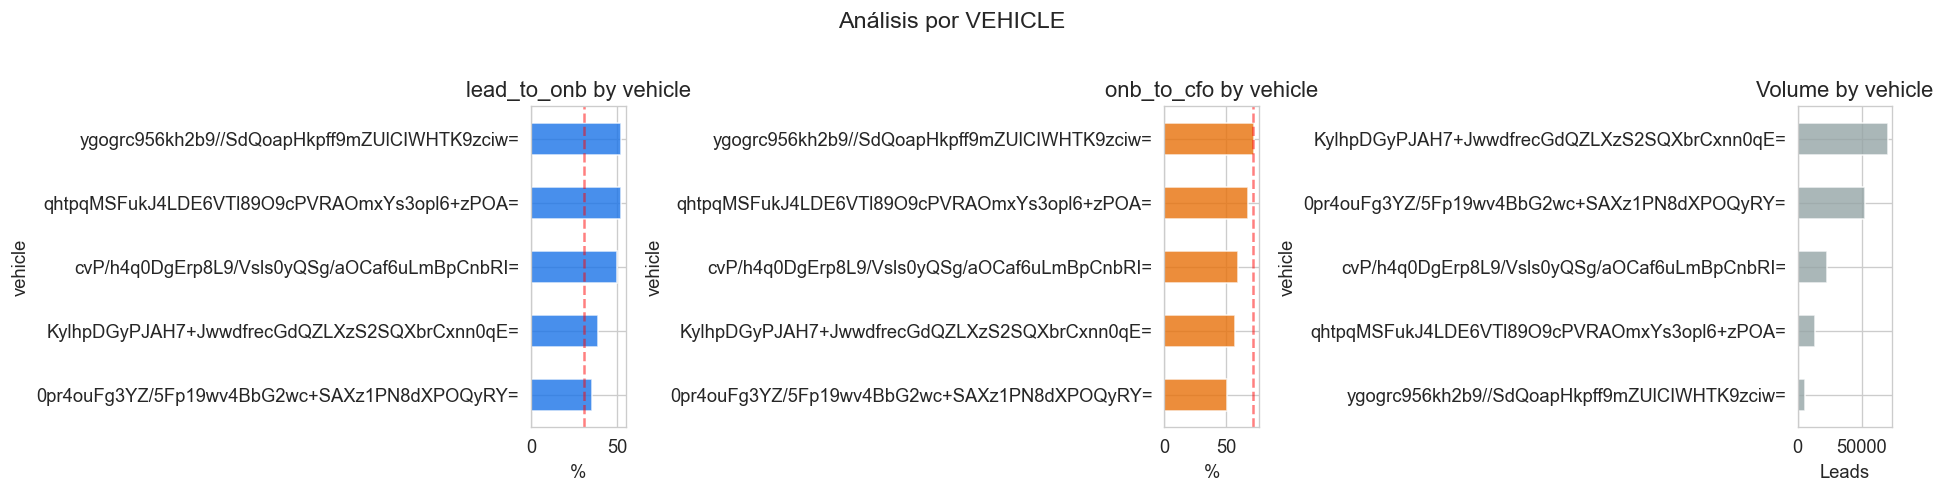


>> COMPANY_NAME
                     total_leads  onboarded    cfo  lead_to_onb  onb_to_cfo
Eternis PL                 37480      16320   9989         43.5        61.2
Evelstar PL                21453      10392   5274         48.4        50.8
City Drive PL              16824       6061   3450         36.0        56.9
Avalon Logistics PL        12360       6090   3788         49.3        62.2
Natviol PL                 11879       7031   3953         59.2        56.2
Sami Group PL              10635       6376   3806         60.0        59.7
Promin PL                   6834       4631   2415         67.8        52.1
MB partner PL               6520       2720   1498         41.7        55.1
Flow Apps PL                4558       2173   1254         47.7        57.7
PTD Partner PL              4123       1780    938         43.2        52.7
Qiwi Partner PL             3092       1554    914         50.3        58.8
One Fleet PL                2045       1175    736         57.5        

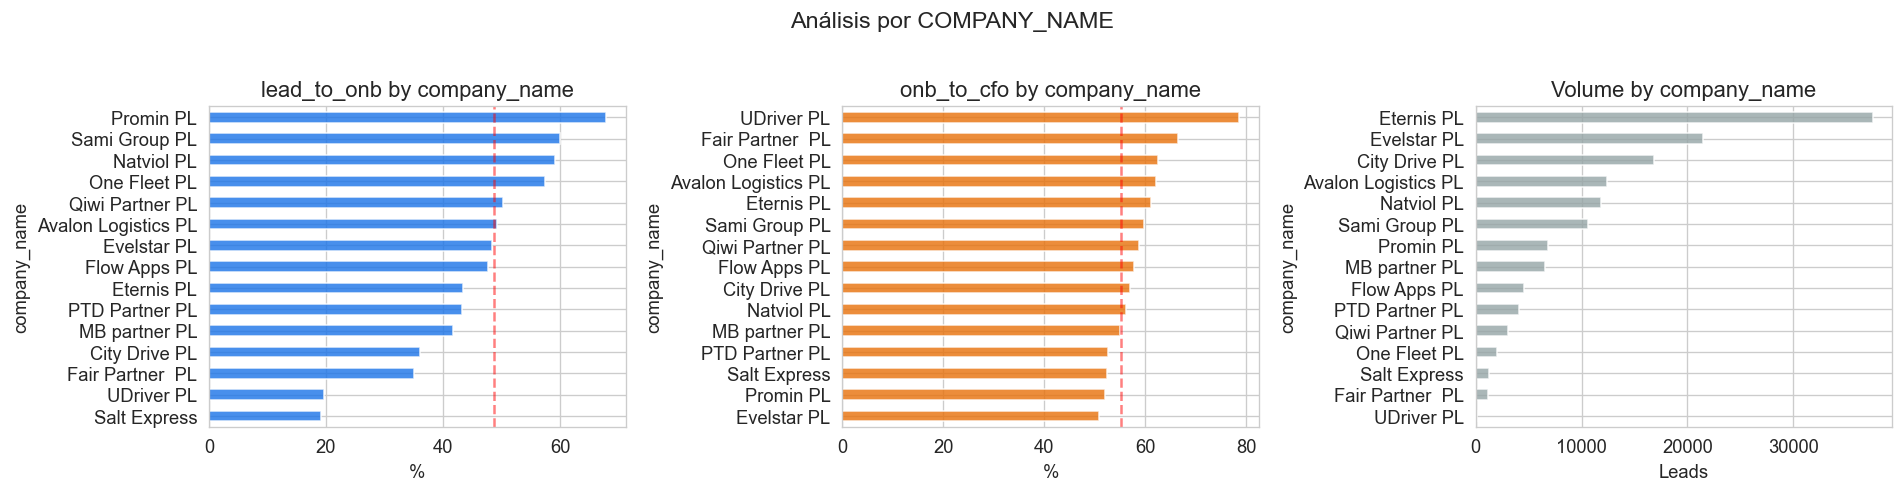


>> REGISTERED_VIA_WEB
       total_leads  onboarded    cfo  lead_to_onb  onb_to_cfo
1.0         137849      58661  33414         42.6        57.0
0.0          26618       8314   5003         31.2        60.2
TOTAL       164467      66975  38417         40.7        57.4


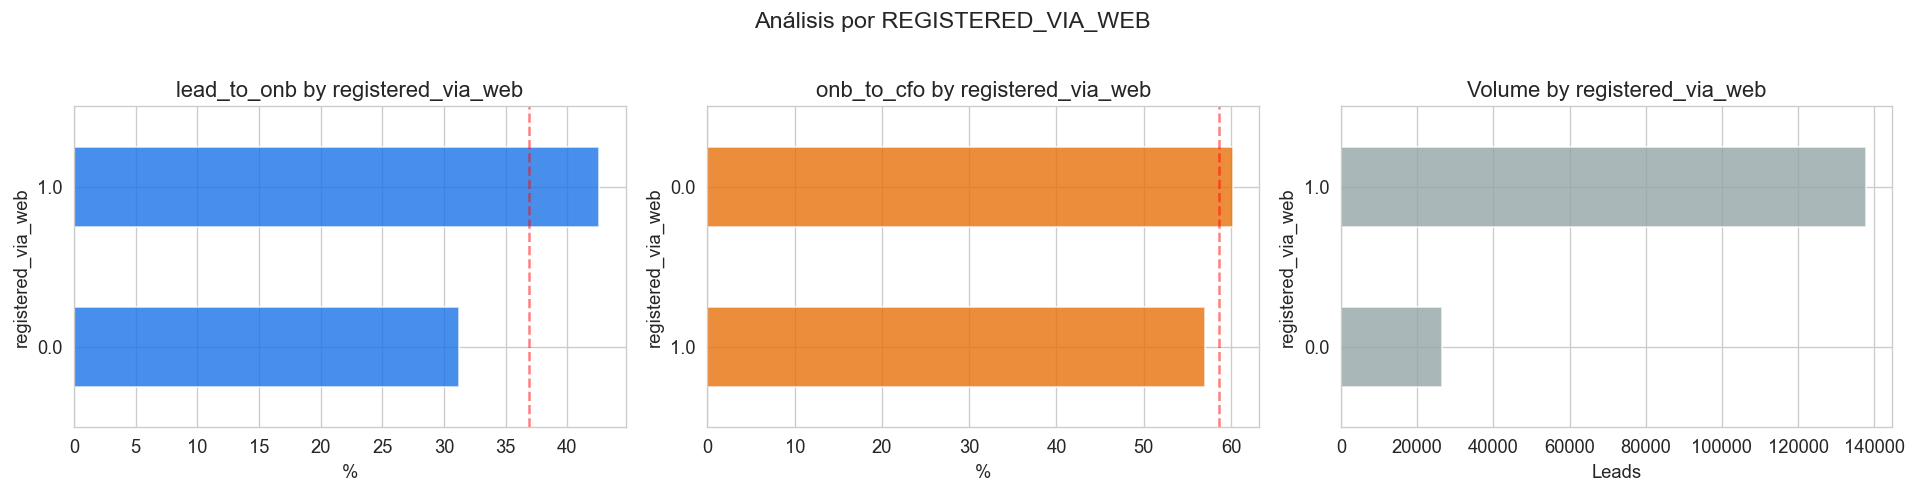

In [20]:
# Análisis por cada variable cualitativa
variables = ['source', 'vehicle', 'company_name', 'registered_via_web']
results = {}
for var in variables:
    results[var] = analyze_variable(df, var)



>> APPLY_SEASON [Solo 2025]
        total_leads  onboarded    cfo  lead_to_onb  onb_to_cfo
summer        50356      20460  11506         40.6        56.2
autumn        49347      20472  12442         41.5        60.8
spring        26000      12732   6866         49.0        53.9
winter        11214       4822   2845         43.0        59.0
TOTAL        136917      58486  33659         42.7        57.6


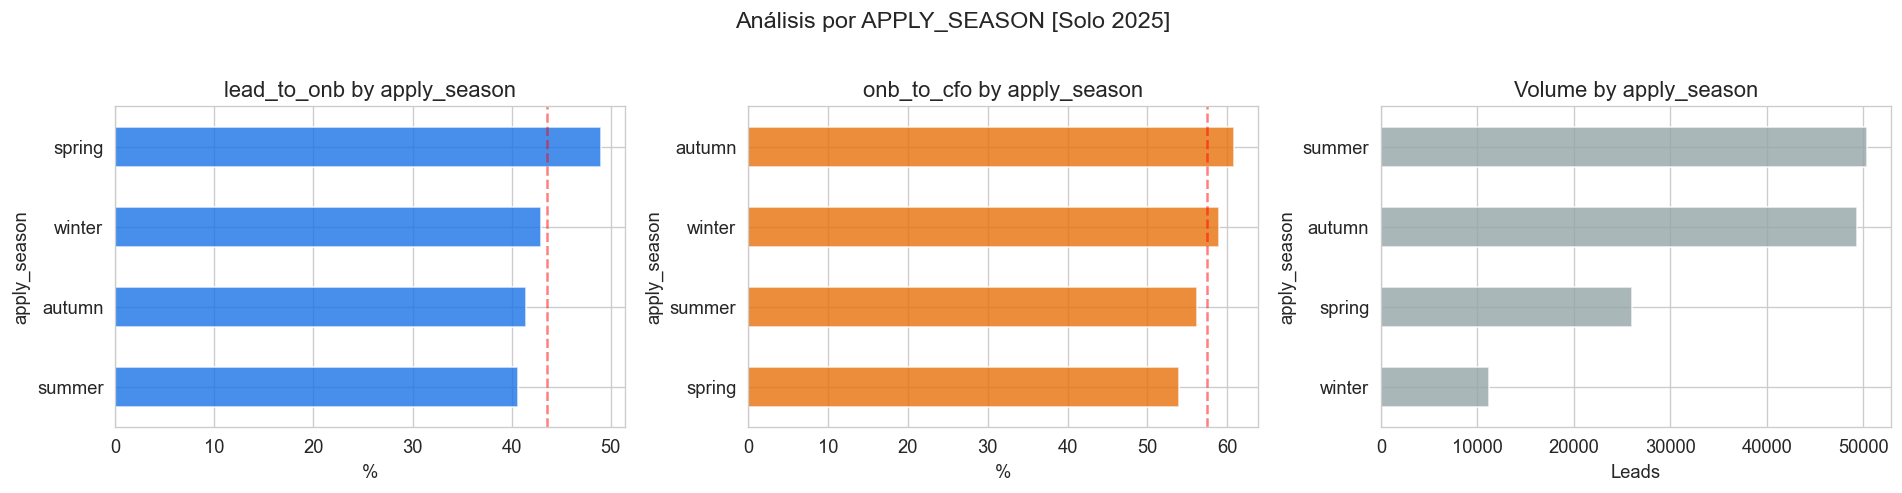

In [21]:
# Apply season: solo 2025 para tener estaciones completas
results['apply_season'] = analyze_variable(df, 'apply_season', filter_year=2025)


## 5. Velocidad del funnel: tiempos por fase

Análisis de tiempos medianos entre fases, segmentado por variables cualitativas y por outcome (CFO vs no CFO).


In [22]:
# 5.1 Tiempos medianos globales
print("--- TIEMPOS MEDIANOS POR FASE (días) ---")
time_stats = df[time_cols].describe().T[['count', 'mean', '50%']]
time_stats.columns = ['Leads válidos', 'Media', 'Mediana']
print(time_stats.round(2))


--- TIEMPOS MEDIANOS POR FASE (días) ---
                      Leads válidos  Media  Mediana
Pending 3PL                 85318.0   0.53     0.00
Document Collection        100111.0   1.03     0.00
Document Review             79535.0   1.30     0.09
Waiting List                77954.0   3.15     0.00
Equipment Collection        70517.0   2.21     0.62
Lead to ONB                 67025.0  10.49     3.83


--- TIEMPOS MEDIANOS: CFO vs NO CFO ---
                      No CFO  Sí CFO  Diferencia (días)  N datos
Pending 3PL             0.00    0.00               0.00    85318
Document Collection     0.00    0.00               0.00   100111
Document Review         0.10    0.08               0.02    79535
Waiting List            0.00    0.00               0.00    77954
Equipment Collection    0.63    0.62               0.01    70517
Lead to ONB             5.96    2.83               3.13    67025


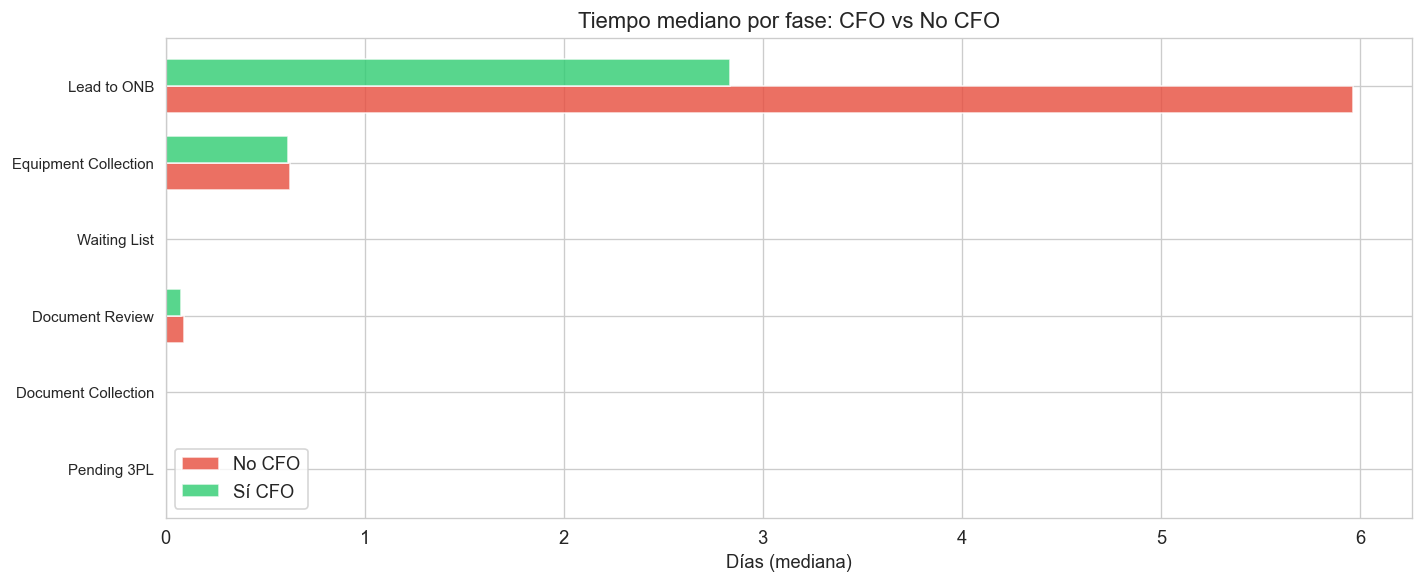

In [23]:
# 5.2 Tiempos por CFO vs No CFO
print("--- TIEMPOS MEDIANOS: CFO vs NO CFO ---")
tiempos_cfo = df.groupby('is_cfo')[time_cols].median().T
tiempos_cfo.columns = ['No CFO', 'Sí CFO']
tiempos_cfo['Diferencia (días)'] = tiempos_cfo['No CFO'] - tiempos_cfo['Sí CFO']
tiempos_cfo['N datos'] = df[time_cols].notna().sum()
print(tiempos_cfo.round(2))

# Gráfico
fig, ax = plt.subplots(figsize=(12, 5))
tiempos_plot = tiempos_cfo[['No CFO', 'Sí CFO']].dropna()
x = range(len(tiempos_plot))
w = 0.35
ax.barh([i - w/2 for i in x], tiempos_plot['No CFO'], w, label='No CFO', color=COLORS['danger'], alpha=0.8)
ax.barh([i + w/2 for i in x], tiempos_plot['Sí CFO'], w, label='Sí CFO', color=COLORS['success'], alpha=0.8)
ax.set_yticks(x)
ax.set_yticklabels(tiempos_plot.index, fontsize=9)
ax.set_xlabel('Días (mediana)')
ax.set_title('Tiempo mediano por fase: CFO vs No CFO')
ax.legend()
plt.tight_layout()
plt.show()


--- TIEMPOS MEDIANOS POR SOURCE ---

Pending 3PL:
source
3PL             0.0
JOB PLATFORM    0.0
ORGANIC         0.0
PERF MKT        0.0
REFERRAL        0.0
RIDER WEB       0.0

Document Collection:
source
3PL             0.00
REFERRAL        0.00
PERF MKT        0.00
ORGANIC         0.00
RIDER WEB       0.01
JOB PLATFORM    0.01

Document Review:
source
JOB PLATFORM    0.06
3PL             0.07
REFERRAL        0.07
ORGANIC         0.11
PERF MKT        0.13
RIDER WEB       0.21

Waiting List:
source
3PL             0.0
JOB PLATFORM    0.0
ORGANIC         0.0
PERF MKT        0.0
REFERRAL        0.0
RIDER WEB       0.0

Equipment Collection:
source
REFERRAL        0.21
3PL             0.25
JOB PLATFORM    0.69
PERF MKT        0.73
ORGANIC         0.74
RIDER WEB       0.79

Lead to ONB:
source
REFERRAL        1.82
3PL             2.64
PERF MKT        5.05
ORGANIC         5.12
RIDER WEB       7.17
JOB PLATFORM    7.63


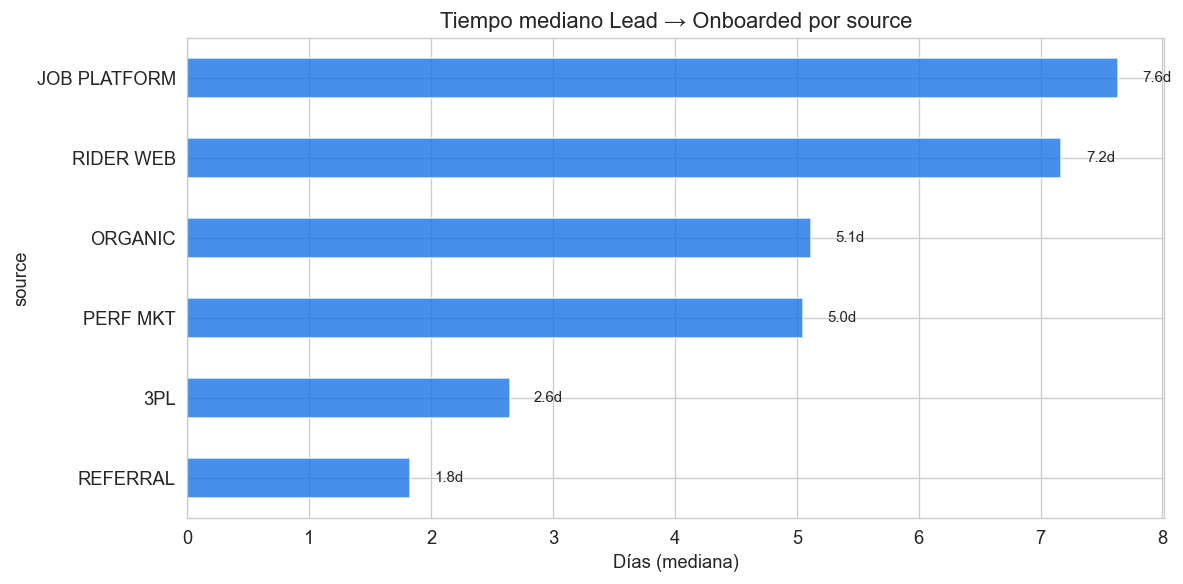

In [24]:
# 5.3 Tiempos por source
print("--- TIEMPOS MEDIANOS POR SOURCE ---")
for col in time_cols:
    if df[col].notna().sum() > 50:
        time_by_source = df.groupby('source')[col].median().sort_values()
        if time_by_source.notna().sum() > 1:
            print(f"\n{col}:")
            print(time_by_source.round(2).to_string())

# Gráfico: lead_to_hired por source
fig, ax = plt.subplots(figsize=(10, 5))
lead_time_source = df.groupby('source')['Lead to ONB'].median().dropna().sort_values()
lead_time_source.plot.barh(ax=ax, color=COLORS['primary'], alpha=0.8, edgecolor='white')
ax.set_xlabel('Días (mediana)')
ax.set_title('Tiempo mediano Lead → Onboarded por source')
for i, v in enumerate(lead_time_source.values):
    if not np.isnan(v):
        ax.text(v + 0.2, i, f'{v:.1f}d', va='center', fontsize=9)
plt.tight_layout()
plt.show()


--- TIEMPOS MEDIANOS POR VEHICLE ---
                                              Pending 3PL  Document Collection  Document Review  Waiting List  Equipment Collection  Lead to ONB
vehicle                                                                                                                                         
/Z0PNsoC01lXHrwka610p9pNWdugaU5qJi2npnzWZ1c=         0.04                 0.00             0.04          0.01                  0.00          NaN
0Qp2imvhLsnmgOC2oKreU6m3R0zBieBQ+l3X7uMHd7I=         0.00                 1.18             5.83          0.00                  0.00          NaN
0pr4ouFg3YZ/5Fp19wv4BbG2wc+SAXz1PN8dXPOQyRY=         0.00                 0.01             0.09          0.00                  0.70         5.63
47DEQpj8HBSa+/TImW+5JCeuQeRkm5NMpJWZG3hSuFU=         0.00                 0.00             0.00          0.00                  2.96         2.97
4U3qHu7O4ReEwkomKjA6UUzTgNpOc1MEPAmrbpuepD0=         0.00                 0.00             0.

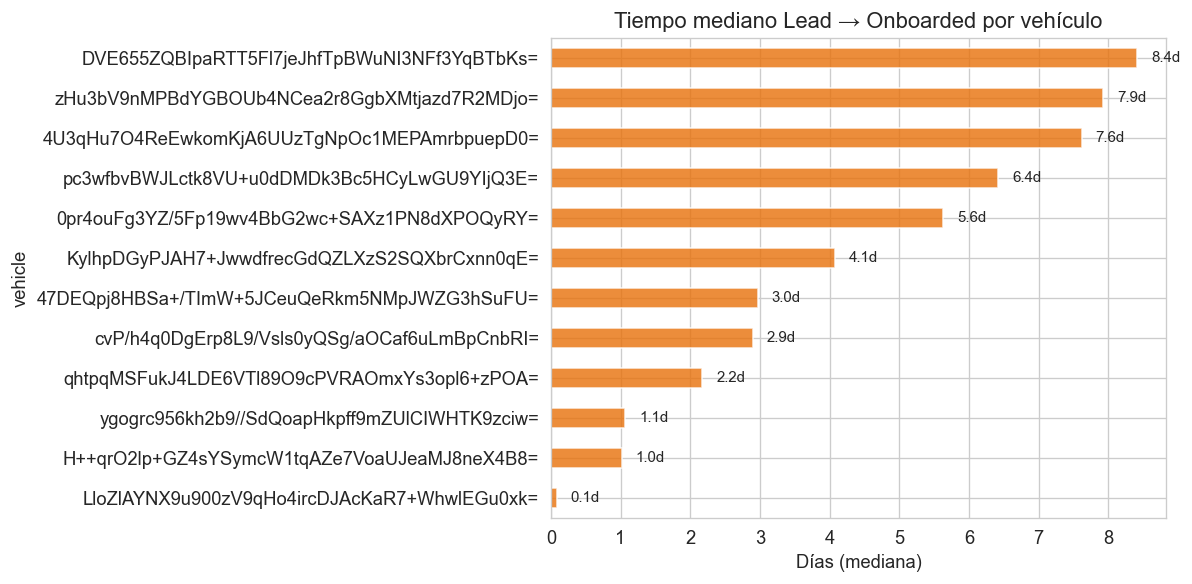

In [25]:
# 5.4 Tiempos por vehicle
print("--- TIEMPOS MEDIANOS POR VEHICLE ---")
time_by_vehicle = df.groupby('vehicle')[time_cols].median()
print(time_by_vehicle.round(2).to_string())

fig, ax = plt.subplots(figsize=(10, 5))
lead_time_vehicle = df.groupby('vehicle')['Lead to ONB'].median().dropna().sort_values()
lead_time_vehicle.plot.barh(ax=ax, color=COLORS['secondary'], alpha=0.8, edgecolor='white')
ax.set_xlabel('Días (mediana)')
ax.set_title('Tiempo mediano Lead → Onboarded por vehículo')
for i, v in enumerate(lead_time_vehicle.values):
    if not np.isnan(v):
        ax.text(v + 0.2, i, f'{v:.1f}d', va='center', fontsize=9)
plt.tight_layout()
plt.show()


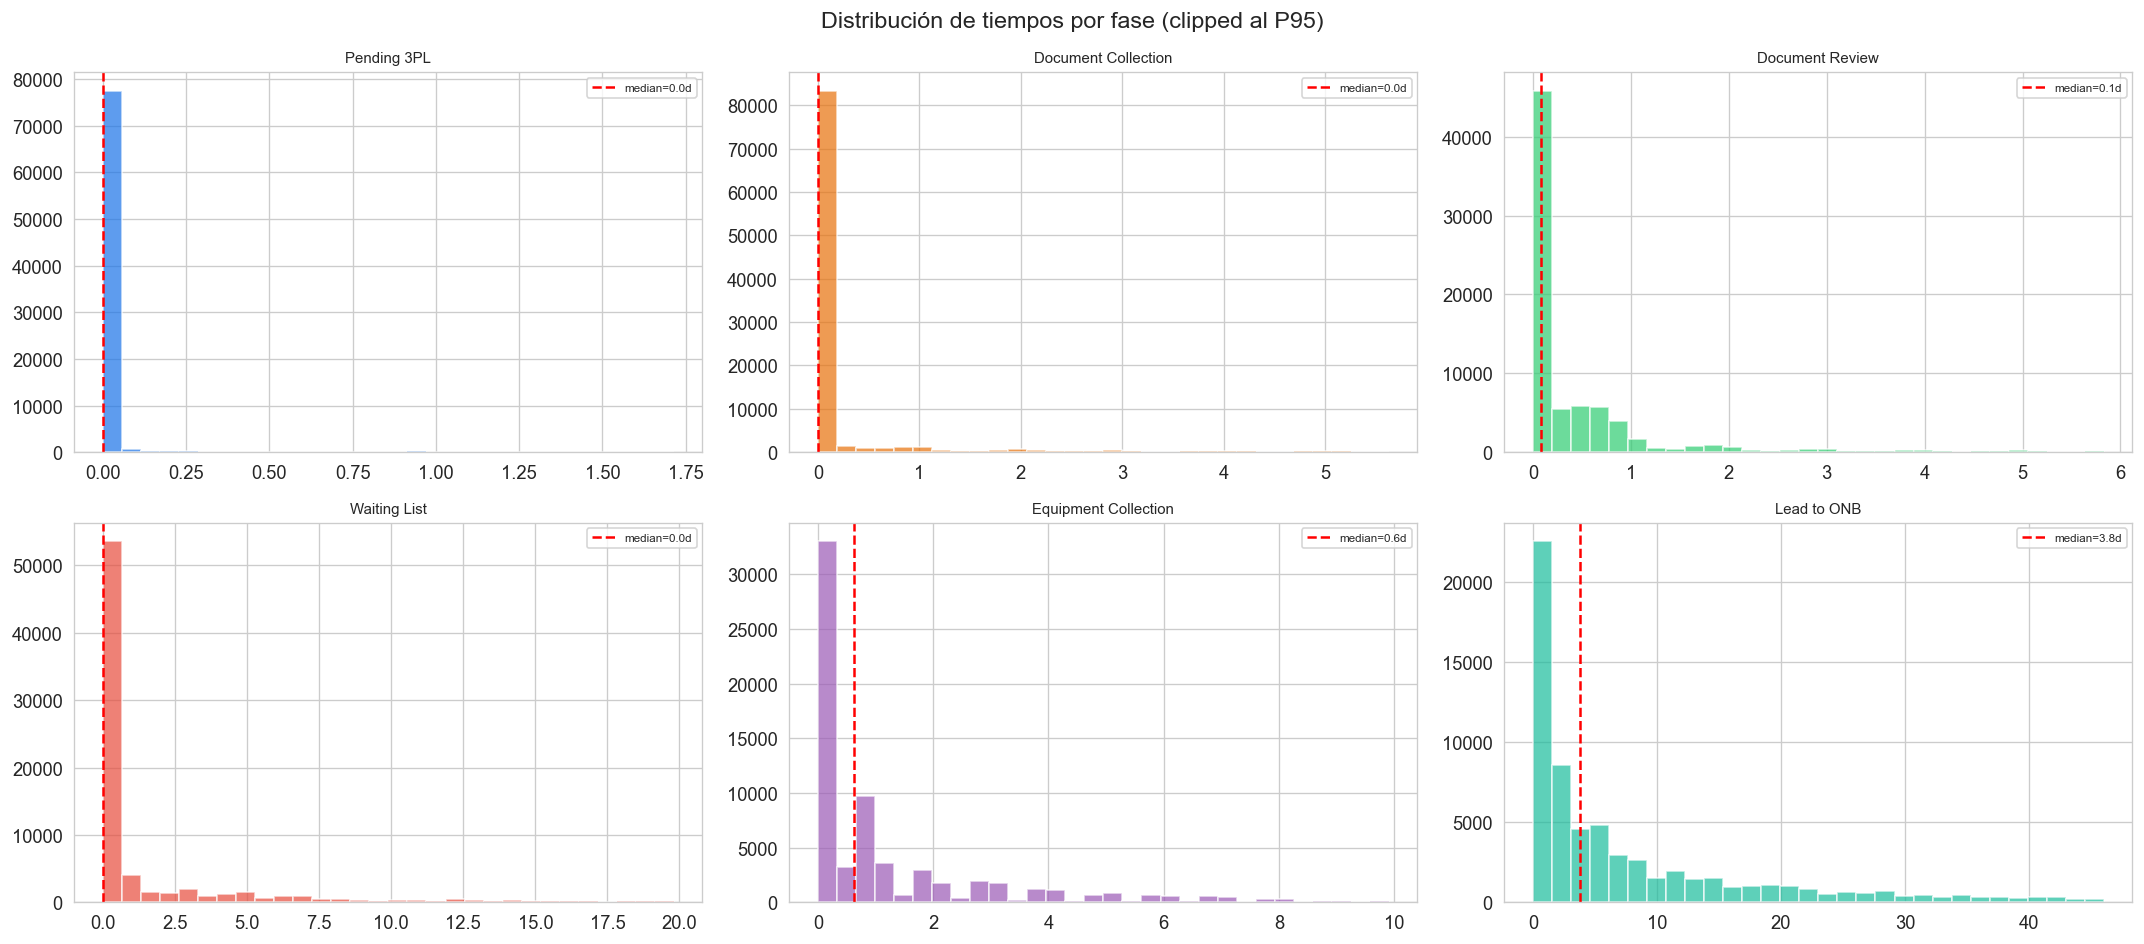

In [26]:
# 5.5 Distribución de tiempos por fase (histogramas)
n_cols_plot = len(time_cols)
n_rows = (n_cols_plot + 2) // 3  # 3 columnas por fila
fig, axes = plt.subplots(n_rows, 3, figsize=(18, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(time_cols):
    data = df[col].dropna()
    if len(data) > 10:
        # Clip outliers for visualization
        upper = data.quantile(0.95)
        data_clipped = data[data <= upper]
        axes[i].hist(data_clipped, bins=30, color=COLORS['palette'][i % len(COLORS['palette'])], 
                     alpha=0.7, edgecolor='white')
        axes[i].axvline(data.median(), color='red', linestyle='--', linewidth=1.5, label=f'median={data.median():.1f}d')
        axes[i].set_title(col, fontsize=9)
        axes[i].legend(fontsize=7)
    else:
        axes[i].text(0.5, 0.5, f'{col}\n(N={len(data)})', ha='center', va='center', transform=axes[i].transAxes)

# Ocultar ejes sobrantes
for j in range(len(time_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribución de tiempos por fase (clipped al P95)', fontsize=14)
plt.tight_layout()
plt.show()

## 5. Análisis por ciudad

Comparación de métricas clave entre las principales ciudades polacas.


In [27]:
# 6.1 Métricas por ciudad
city_stats = df.groupby('city_code').agg(
    leads=('applicant_id', 'count'),
    onboarded=('was_hired', 'sum'),
    cfo=('is_cfo', 'sum'),
    median_time=('Lead to ONB', 'median')
).sort_values('leads', ascending=False)

city_stats['lead_to_onb'] = (city_stats['onboarded'] / city_stats['leads'] * 100).round(1)
city_stats['onb_to_cfo'] = (city_stats['cfo'] / city_stats['onboarded'].replace(0, np.nan) * 100).round(1)
city_stats['median_time'] = city_stats['median_time'].round(1)

print("Métricas por ciudad:")
print(city_stats.to_string())


Métricas por ciudad:
           leads  onboarded   cfo  median_time  lead_to_onb  onb_to_cfo
city_code                                                              
WAW        30312      14963  8787          1.7         49.4        58.7
KRA        11885       5361  3575          2.7         45.1        66.7
WRO         9475       3984  2241          5.6         42.0        56.2
POZ         8924       3940  2350          3.1         44.2        59.6
LOD         8480       3900  2662          3.0         46.0        68.3
GDN         7567       4167  2626          1.5         55.1        63.0
KTW         4536       1666   898          5.1         36.7        53.9
SZZ         3782       1696  1026          2.1         44.8        60.5
BZG         3129       1343   752          4.8         42.9        56.0
SZY         2191        914   546          3.9         41.7        59.7
QLU         2187        923   521          6.7         42.2        56.4
TUN         2122        751   392          

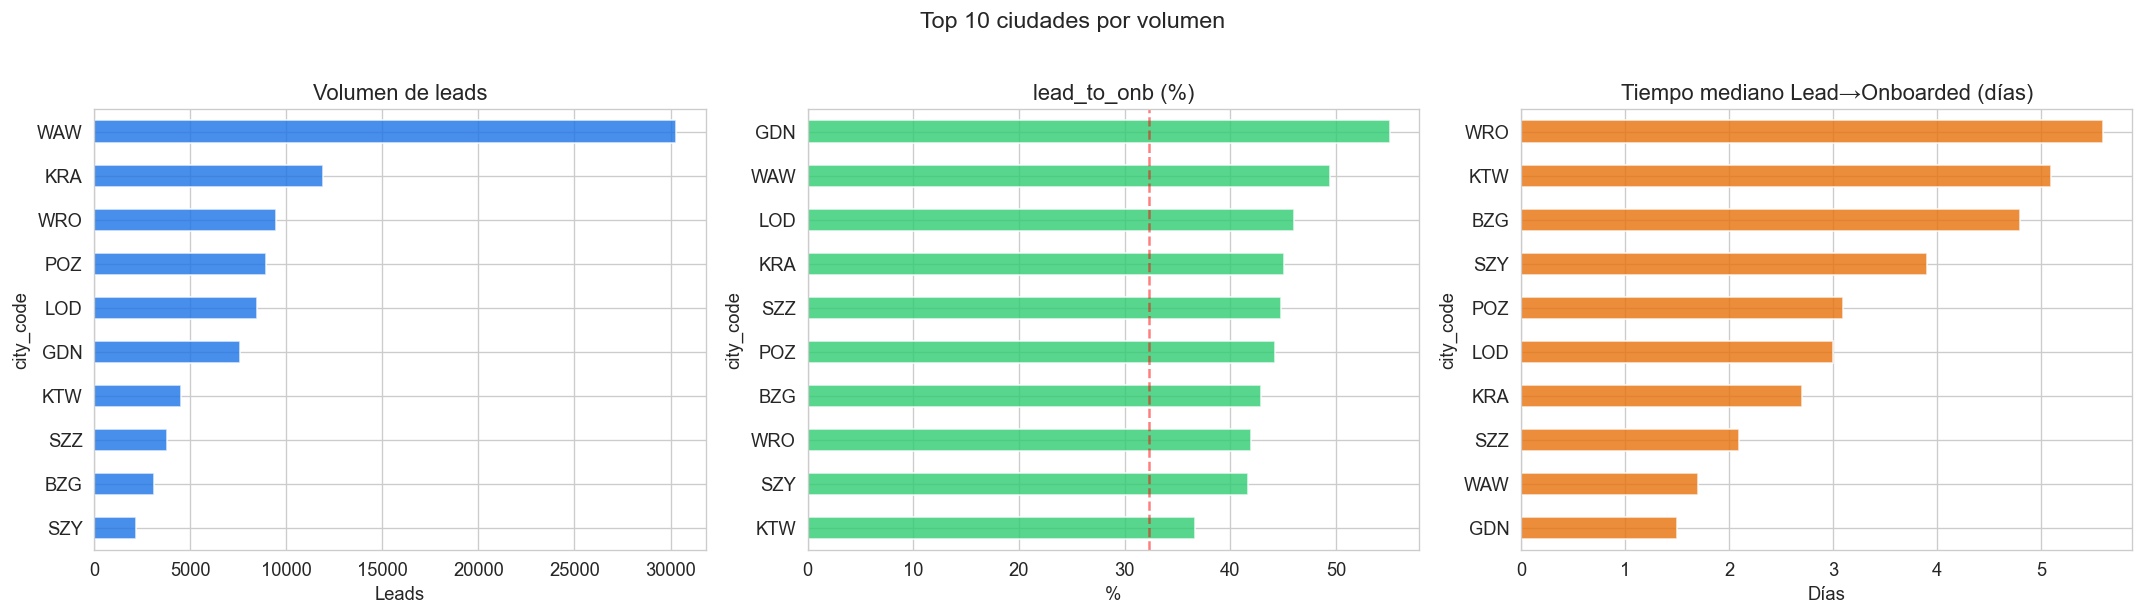

In [28]:
# Top 10 ciudades por volumen
top_cities = city_stats.head(10)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

top_cities['leads'].sort_values().plot.barh(ax=axes[0], color=COLORS['primary'], alpha=0.8)
axes[0].set_title('Volumen de leads')
axes[0].set_xlabel('Leads')

top_cities['lead_to_onb'].sort_values().plot.barh(ax=axes[1], color=COLORS['success'], alpha=0.8)
axes[1].set_title('lead_to_onb (%)')
axes[1].set_xlabel('%')
axes[1].axvline(city_stats['lead_to_onb'].mean(), color='red', linestyle='--', alpha=0.5)

top_cities['median_time'].sort_values().plot.barh(ax=axes[2], color=COLORS['secondary'], alpha=0.8)
axes[2].set_title('Tiempo mediano Lead→Onboarded (días)')
axes[2].set_xlabel('Días')

plt.suptitle('Top 10 ciudades por volumen', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


## 8. Evolución temporal (cohortes mensuales)

¿Están mejorando o empeorando las métricas mes a mes?


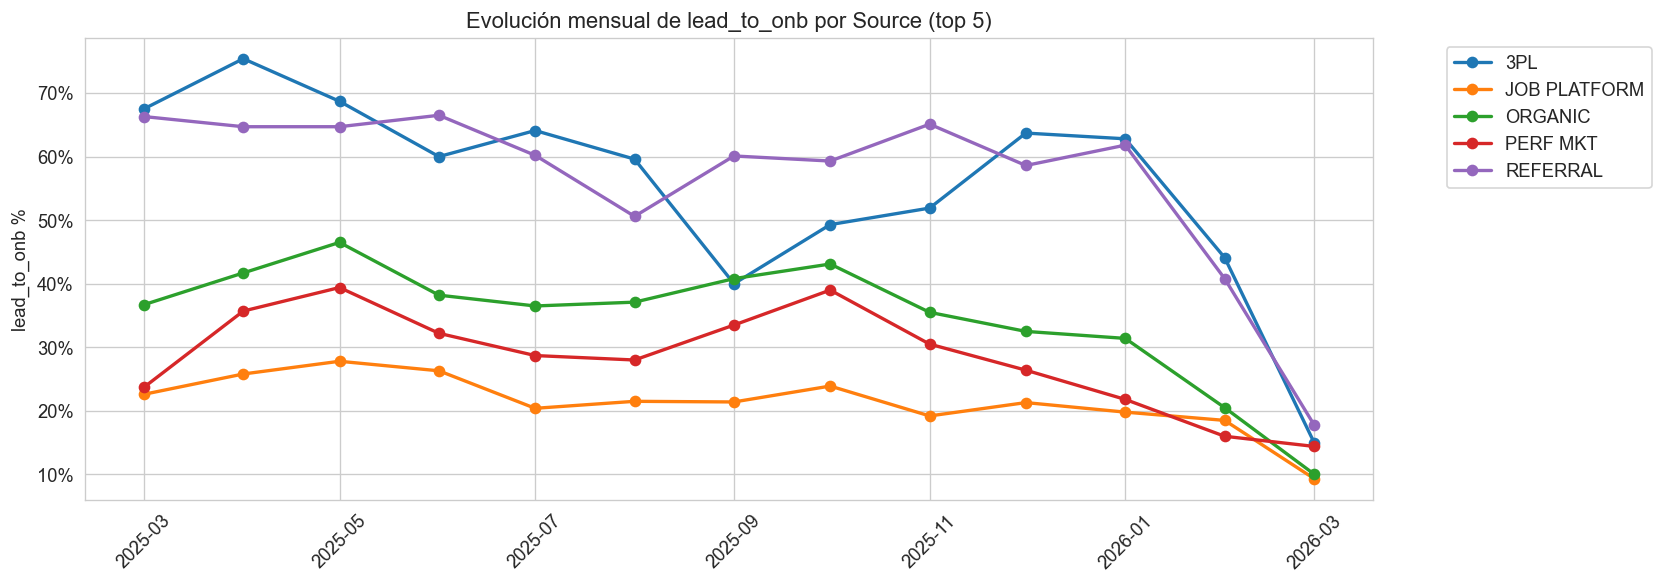

In [29]:
# 8.1 Evolución de lead_to_onb por source
sources_top = df['source'].value_counts().head(5).index.tolist()
df_top_sources = df[df['source'].isin(sources_top)]

pivot_monthly_source = df_top_sources.groupby(['month', 'source'])['was_hired'].mean().unstack()
pivot_monthly_source = (pivot_monthly_source * 100).round(1)

fig, ax = plt.subplots(figsize=(14, 5))
for col in pivot_monthly_source.columns:
    ax.plot(pivot_monthly_source.index, pivot_monthly_source[col], marker='o', label=col, linewidth=2)
ax.set_ylabel('lead_to_onb %')
ax.set_title('Evolución mensual de lead_to_onb por Source (top 5)')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.tick_params(axis='x', rotation=45)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
plt.tight_layout()
plt.show()


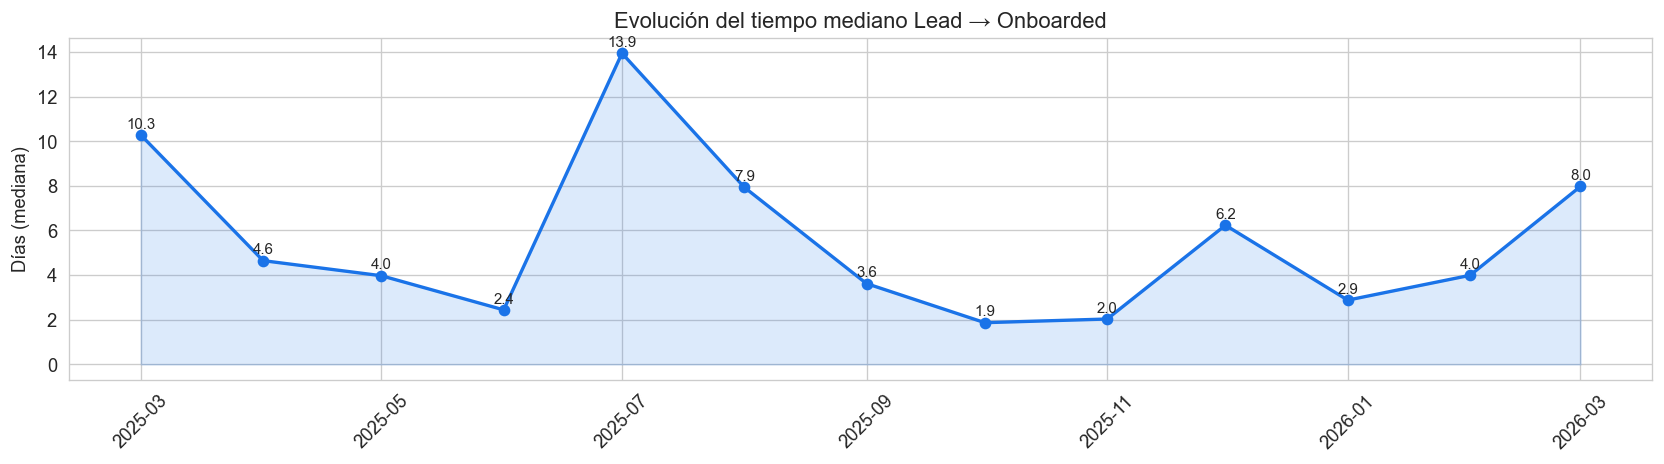

In [30]:
# 8.2 Evolución del tiempo mediano lead → onboarded
monthly_time = df.groupby('month')['Lead to ONB'].median()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(monthly_time.index, monthly_time.values, marker='o', color=COLORS['primary'], linewidth=2)
ax.fill_between(monthly_time.index, monthly_time.values, alpha=0.15, color=COLORS['primary'])
ax.set_ylabel('Días (mediana)')
ax.set_title('Evolución del tiempo mediano Lead → Onboarded')
ax.tick_params(axis='x', rotation=45)
for i, (date, val) in enumerate(monthly_time.items()):
    if not np.isnan(val):
        ax.text(date, val + 0.3, f'{val:.1f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()


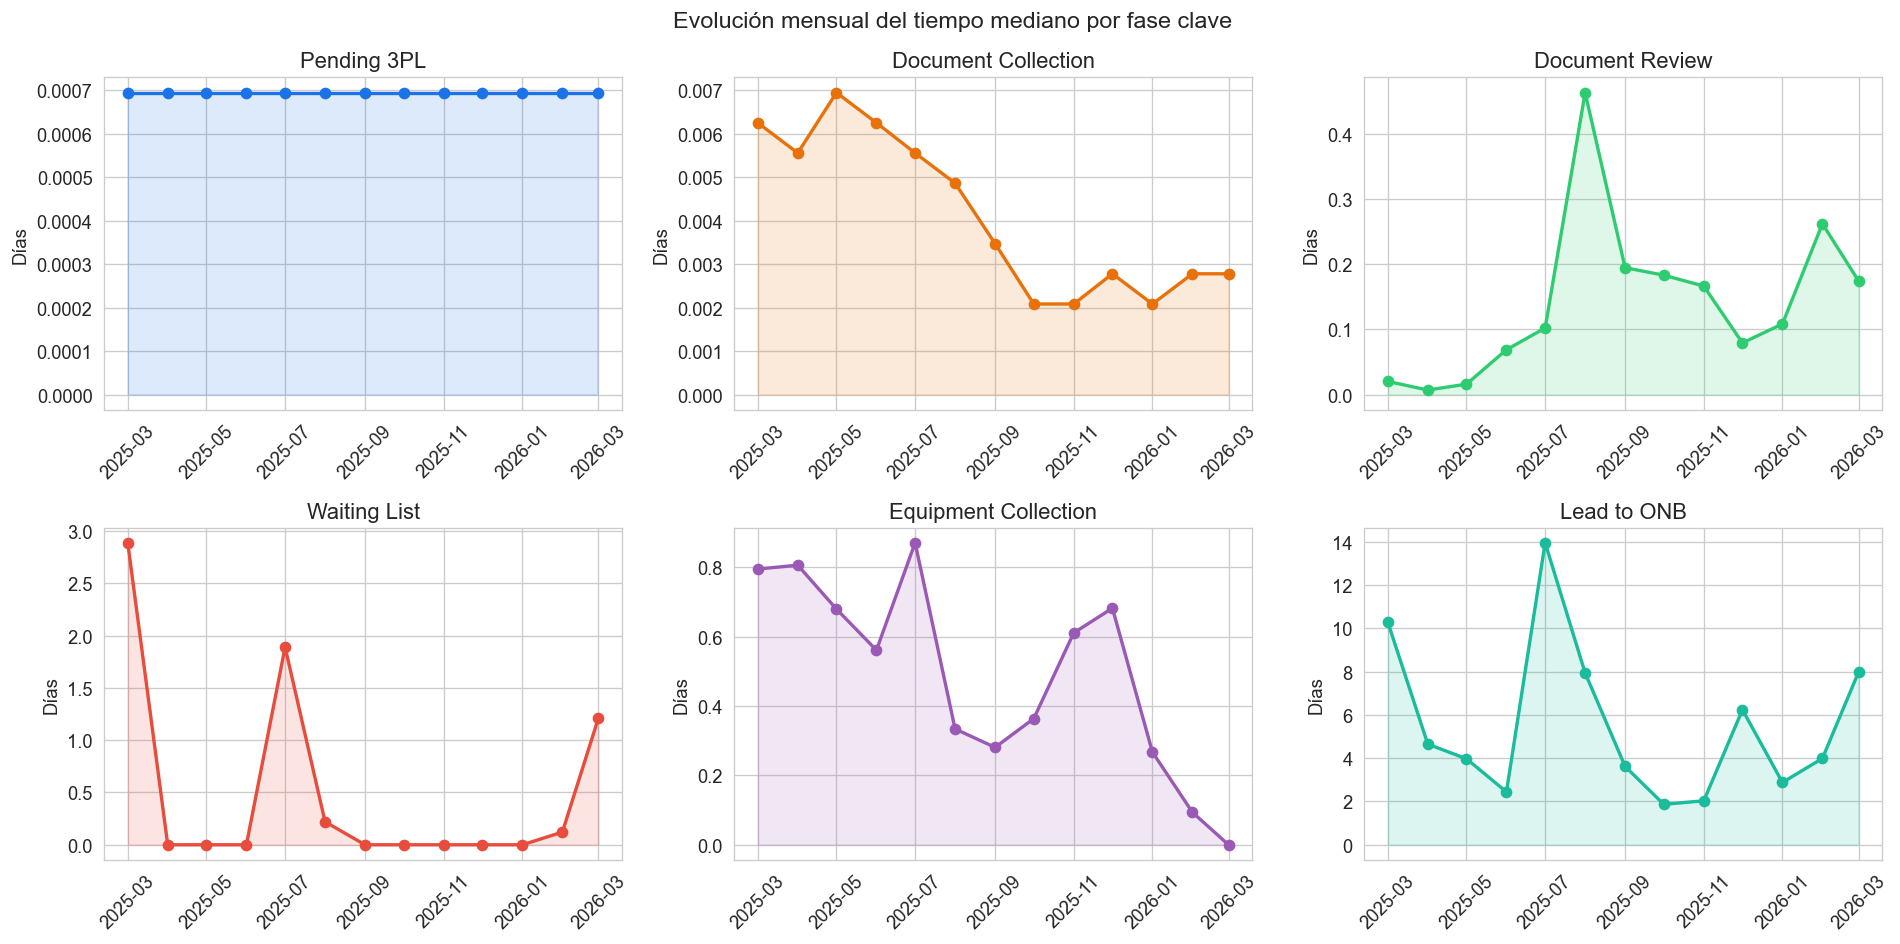

In [31]:
# 8.3 Evolución de velocidad por fase
n_cols_plot = len(time_cols)
n_rows = (n_cols_plot + 2) // 3
fig, axes = plt.subplots(n_rows, 3, figsize=(16, 4 * n_rows))
axes = axes.flatten()

for i, phase in enumerate(time_cols):
    monthly_phase = df.groupby('month')[phase].median()
    axes[i].plot(monthly_phase.index, monthly_phase.values, marker='o', color=COLORS['palette'][i % len(COLORS['palette'])], linewidth=2)
    axes[i].fill_between(monthly_phase.index, monthly_phase.values, alpha=0.15, color=COLORS['palette'][i % len(COLORS['palette'])])
    axes[i].set_title(phase)
    axes[i].set_ylabel('Días')
    axes[i].tick_params(axis='x', rotation=45)

# Ocultar ejes sobrantes
for j in range(len(time_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Evolución mensual del tiempo mediano por fase clave', fontsize=14)
plt.tight_layout()
plt.show()

## 9. Análisis por tipo de workflow

Poland tiene 2 workflows con fases distintas:
- **Other leads PL** (6 stages): Pending 3PL → Document Collection → Document Review → Waiting List → Equipment Collection → Hired
- **3PL already assigned leads PL** (5 stages): Document Collection → Document Review → Waiting List → Equipment Collection → Hired

A continuación segmentamos todos los análisis clave por workflow.

In [32]:
# Configuración por workflow
WORKFLOWS = {
    'Other leads PL': {
        'label': 'Other leads PL (con asignación 3PL)',
        'time_cols': ['Pending 3PL', 'Document Collection', 'Document Review',
                      'Waiting List', 'Equipment Collection', 'Lead to ONB']
    },
    '3PL already assigned leads PL': {
        'label': '3PL already assigned leads PL (sin asignación 3PL)',
        'time_cols': ['Document Collection', 'Document Review',
                      'Waiting List', 'Equipment Collection', 'Lead to ONB']
    }
}

# Verificar volúmenes
for wf_name, cfg in WORKFLOWS.items():
    sub = df[df['workflow_name'] == wf_name]
    print(f"{cfg['label']}:")
    print(f"  Leads: {len(sub):,} | Hired: {sub['was_hired'].sum():,} ({sub['was_hired'].mean():.1%}) | CFO: {sub['is_cfo'].sum():,} ({sub['is_cfo'].mean():.1%})")
    print(f"  Fases: {cfg['time_cols']}")
    print()

Other leads PL (con asignación 3PL):
  Leads: 109,321 | Hired: 36,121 (33.0%) | CFO: 19,783 (18.1%)
  Fases: ['Pending 3PL', 'Document Collection', 'Document Review', 'Waiting List', 'Equipment Collection', 'Lead to ONB']

3PL already assigned leads PL (sin asignación 3PL):
  Leads: 0 | Hired: 0 (nan%) | CFO: 0 (nan%)
  Fases: ['Document Collection', 'Document Review', 'Waiting List', 'Equipment Collection', 'Lead to ONB']



In [33]:
# 9.1 Volúmenes y conversiones por workflow
for wf_name, cfg in WORKFLOWS.items():
    wf_df = df[df['workflow_name'] == wf_name]
    
    wf_monthly = wf_df.groupby('month').agg(
        leads=('applicant_id', 'count'),
        onboarded=('was_hired', 'sum'),
        cfo=('is_cfo', 'sum')
    ).sort_index()
    
    wf_monthly['lead_to_onb'] = (wf_monthly['onboarded'] / wf_monthly['leads'] * 100).round(1)
    wf_monthly['onb_to_cfo'] = (wf_monthly['cfo'] / wf_monthly['onboarded'].replace(0, np.nan) * 100).round(1)
    
    print(f"\n{'='*80}")
    print(f">> {cfg['label']}")
    print(f"{'='*80}")
    print(wf_monthly.to_string())
    
    # Gráfico
    fig_wf = make_subplots(
        rows=2, cols=1,
        row_heights=[0.65, 0.35],
        subplot_titles=[f"Volumen mensual — {wf_name}", f"Tasas de conversión — {wf_name}"],
        vertical_spacing=0.15
    )
    
    wf_labels = wf_monthly.index.strftime('%b %Y')
    
    fig_wf.add_trace(go.Bar(
        x=wf_labels, y=wf_monthly['leads'], name='Leads',
        marker_color=COLORS['primary'], opacity=0.85,
        text=wf_monthly['leads'].astype(int), textposition='outside', textfont_size=8
    ), row=1, col=1)
    fig_wf.add_trace(go.Bar(
        x=wf_labels, y=wf_monthly['onboarded'], name='Onboarded',
        marker_color=COLORS['success'], opacity=0.85
    ), row=1, col=1)
    fig_wf.add_trace(go.Bar(
        x=wf_labels, y=wf_monthly['cfo'], name='CFO',
        marker_color=COLORS['secondary'], opacity=0.85
    ), row=1, col=1)
    
    fig_wf.add_trace(go.Scatter(
        x=wf_labels, y=wf_monthly['lead_to_onb'], name='lead_to_onb %',
        mode='lines+markers', line=dict(color=COLORS['secondary'], width=2)
    ), row=2, col=1)
    fig_wf.add_trace(go.Scatter(
        x=wf_labels, y=wf_monthly['onb_to_cfo'], name='onb_to_cfo %',
        mode='lines+markers', line=dict(color=COLORS['success'], width=2, dash='dash')
    ), row=2, col=1)
    
    fig_wf.update_layout(barmode='group', height=550, width=900, template='plotly_white',
                         legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='center', x=0.5))
    fig_wf.update_yaxes(title_text='Leads', row=1, col=1)
    fig_wf.update_yaxes(title_text='%', ticksuffix='%', row=2, col=1)
    fig_wf.update_xaxes(tickangle=45)
    fig_wf.show()


>> Other leads PL (con asignación 3PL)
            leads  onboarded   cfo  lead_to_onb  onb_to_cfo
month                                                      
2025-03-01   1340        468   204         34.9        43.6
2025-04-01   6644       2575  1226         38.8        47.6
2025-05-01  10107       4093  2065         40.5        50.5
2025-06-01  16983       5893  3165         34.7        53.7
2025-07-01  10969       3653  1856         33.3        50.8
2025-08-01   9521       3156  1699         33.1        53.8
2025-09-01  13554       4839  2937         35.7        60.7
2025-10-01   8831       3453  1908         39.1        55.3
2025-11-01   7063       2349  1507         33.3        64.2
2025-12-01   6578       1938  1160         29.5        59.9
2026-01-01   7707       2016  1161         26.2        57.6
2026-02-01   8084       1475   790         18.2        53.6
2026-03-01   1940        213   105         11.0        49.3



>> 3PL already assigned leads PL (sin asignación 3PL)
Empty DataFrame
Columns: [leads, onboarded, cfo, lead_to_onb, onb_to_cfo]
Index: []



>> RECHAZOS — Other leads PL (con asignación 3PL)
Total leads con rechazo: 65,295 (59.7% del workflow)

Por categoría:
rejection_category
candidate_withdrawn    57192
recruiter_rejected      8103

Top 10 tipos:
rejection_type
no_interest            34696
unresponsive           22482
duplicate               3946
fraud                   3121
not_old_enough           441
blacklisted              420
spam                     122
work_permit_missing       48
not_a_good_fit            11
not_hiring_atm             5


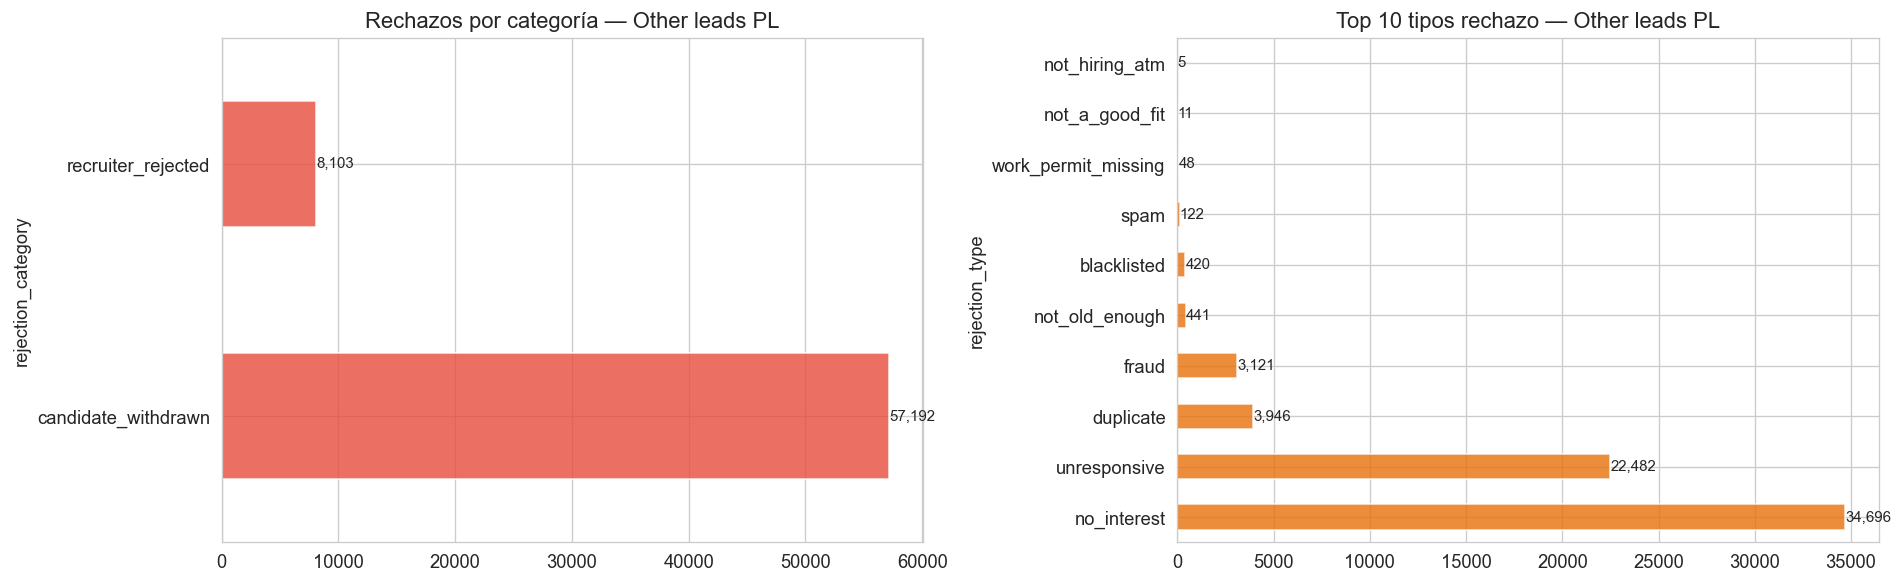


>> RECHAZOS — 3PL already assigned leads PL (sin asignación 3PL)


ZeroDivisionError: division by zero

In [34]:
# 9.2 Rechazos por workflow
for wf_name, cfg in WORKFLOWS.items():
    wf_df = df[df['workflow_name'] == wf_name]
    wf_rejected = wf_df[wf_df['rejection_category'].notna()]
    
    print(f"\n{'='*80}")
    print(f">> RECHAZOS — {cfg['label']}")
    print(f"{'='*80}")
    print(f"Total leads con rechazo: {len(wf_rejected):,} ({len(wf_rejected)/len(wf_df)*100:.1f}% del workflow)")
    
    wf_rej_cat = wf_rejected['rejection_category'].value_counts()
    wf_rej_type = wf_rejected['rejection_type'].value_counts().head(10)
    
    print(f"\nPor categoría:\n{wf_rej_cat.to_string()}")
    print(f"\nTop 10 tipos:\n{wf_rej_type.to_string()}")
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    wf_rej_cat.plot.barh(ax=axes[0], color=COLORS['danger'], alpha=0.8, edgecolor='white')
    axes[0].set_title(f'Rechazos por categoría — {wf_name}')
    for i, v in enumerate(wf_rej_cat.values):
        axes[0].text(v + 5, i, f'{v:,}', va='center', fontsize=9)
    
    wf_rej_type.plot.barh(ax=axes[1], color=COLORS['secondary'], alpha=0.8, edgecolor='white')
    axes[1].set_title(f'Top 10 tipos rechazo — {wf_name}')
    for i, v in enumerate(wf_rej_type.values):
        axes[1].text(v + 5, i, f'{v:,}', va='center', fontsize=9)
    
    plt.tight_layout()
    plt.show()


################################################################################
## Other leads PL (con asignación 3PL)
################################################################################

>> SOURCE
              total_leads  onboarded    cfo  lead_to_onb  onb_to_cfo
ORGANIC             78595      28600  16016         36.4        56.0
PERF MKT            19901       5681   3033         28.5        53.4
JOB PLATFORM        15621       3745   1407         24.0        37.6
RIDER WEB            2878        845    391         29.4        46.3
REFERRAL              194         84     49         43.3        58.3
3PL                    15          8      5         53.3        62.5
OFFLINE                 3          1      0         33.3         0.0
TOTAL              117207      38964  20901         33.2        53.6


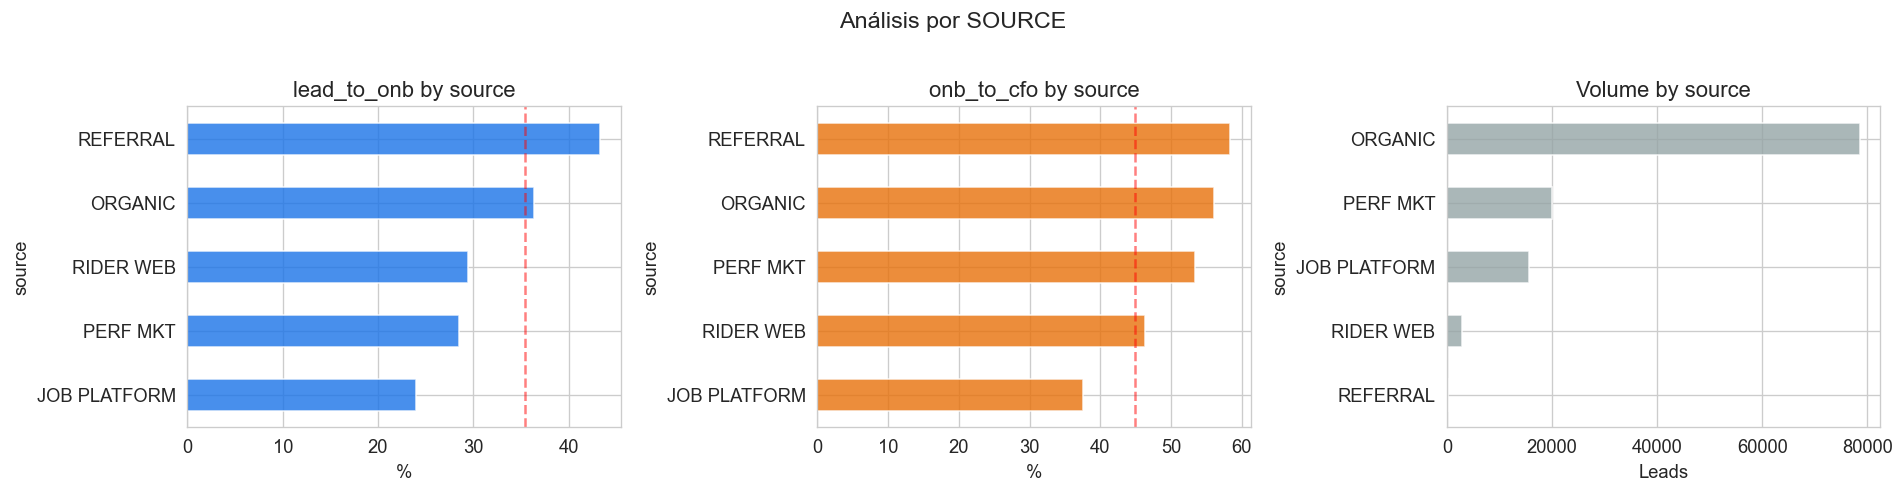


>> COMPANY_NAME
                     total_leads  onboarded    cfo  lead_to_onb  onb_to_cfo
Eternis PL                 23484      11379   6381         48.5        56.1
Evelstar PL                19003       8484   4101         44.6        48.3
City Drive PL              11415       3483   1805         30.5        51.8
Avalon Logistics PL         8254       3658   2219         44.3        60.7
Natviol PL                  7741       4096   2106         52.9        51.4
MB partner PL               5136       1951   1019         38.0        52.2
Sami Group PL               4825       2051   1188         42.5        57.9
Promin PL                   2674       1106    612         41.4        55.3
PTD Partner PL              2500        935    492         37.4        52.6
Flow Apps PL                2238        826    438         36.9        53.0
Salt Express                1185        200     94         16.9        47.0
Qiwi Partner PL             1168        245    156         21.0        

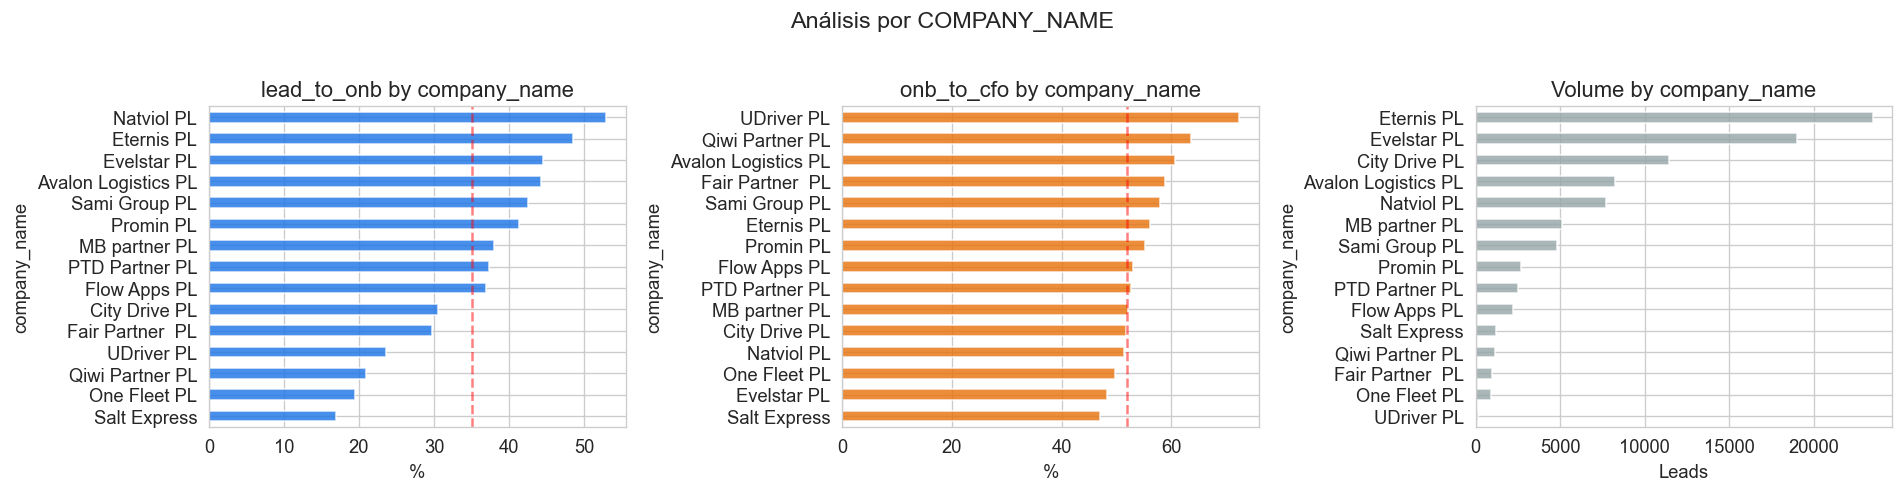


>> REGISTERED_VIA_WEB
       total_leads  onboarded    cfo  lead_to_onb  onb_to_cfo
1.0          88558      29865  15695         33.7        52.6
0.0          28604       9060   5188         31.7        57.3
TOTAL       117162      38925  20883         33.2        53.6


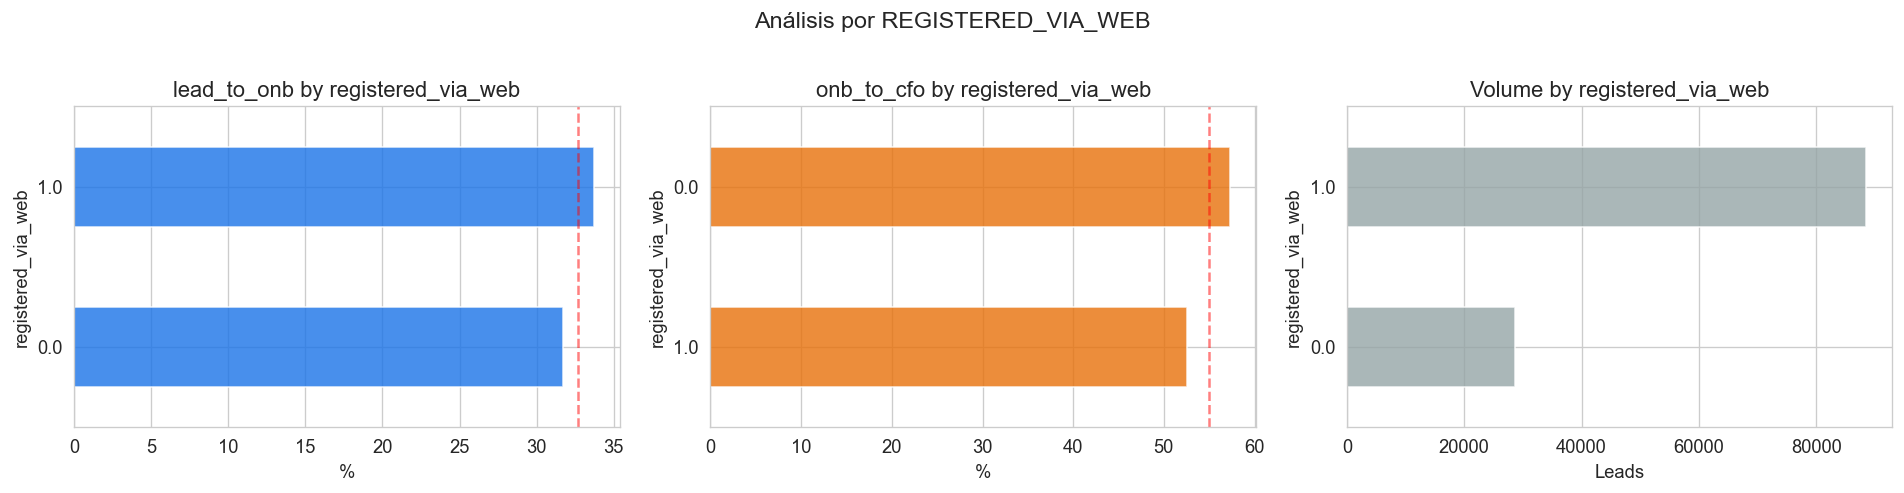


################################################################################
## 3PL already assigned leads PL (sin asignación 3PL)
################################################################################

>> SOURCE
          total_leads  onboarded    cfo  lead_to_onb  onb_to_cfo
3PL             43226      24448  13728         56.6        56.2
REFERRAL        13907       8356   5883         60.1        70.4
ORGANIC           707        326    175         46.1        53.7
PERF MKT            9          2      0         22.2         0.0
TOTAL           57849      33132  19786         57.3        59.7


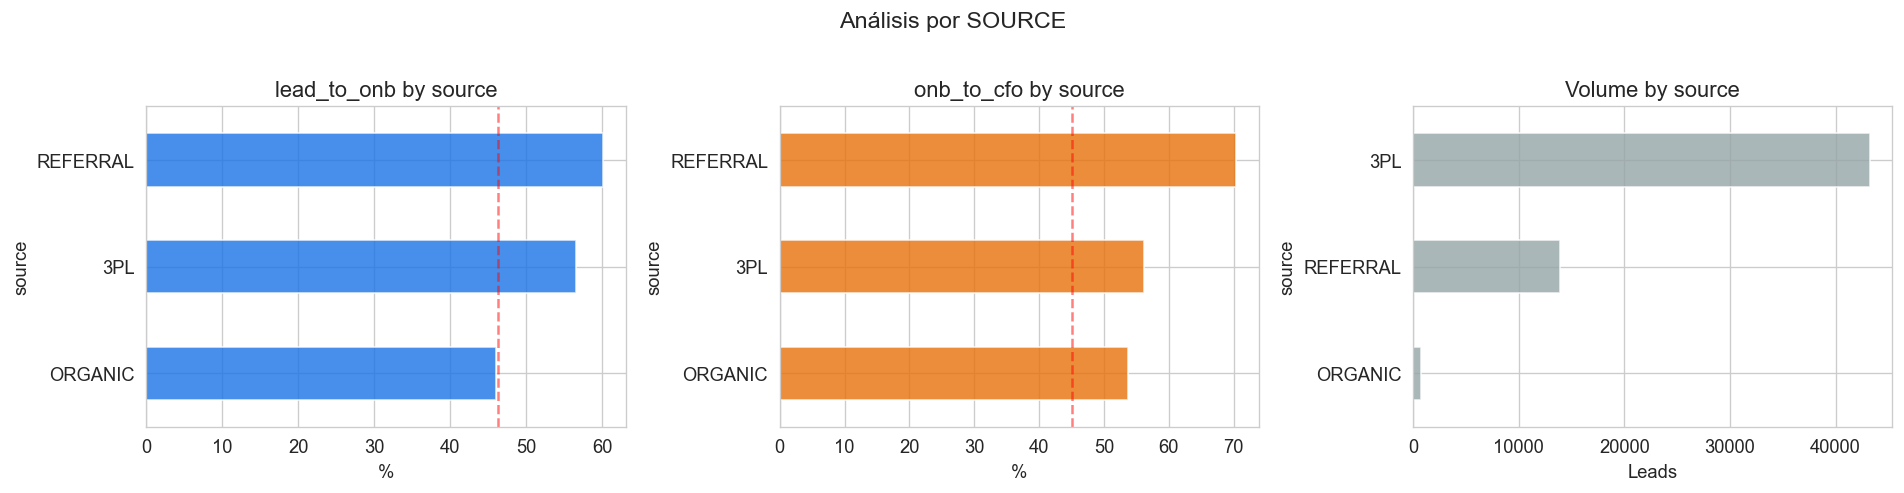


>> COMPANY_NAME
                     total_leads  onboarded    cfo  lead_to_onb  onb_to_cfo
Eternis PL                 16553       6441   4173         38.9        64.8
City Drive PL               6647       3116   1875         46.9        60.2
Sami Group PL               6585       4853   2876         73.7        59.3
Natviol PL                  5360       3566   2113         66.5        59.3
Avalon Logistics PL         5016       2883   1821         57.5        63.2
Promin PL                   4698       3995   1997         85.0        50.0
Evelstar PL                 3499       2233   1349         63.8        60.4
Flow Apps PL                2410       1434    852         59.5        59.4
Qiwi Partner PL             1844       1391    801         75.4        57.6
MB partner PL               1817       1029    615         56.6        59.8
PTD Partner PL              1767        896    464         50.7        51.8
One Fleet PL                1283       1110    705         86.5        

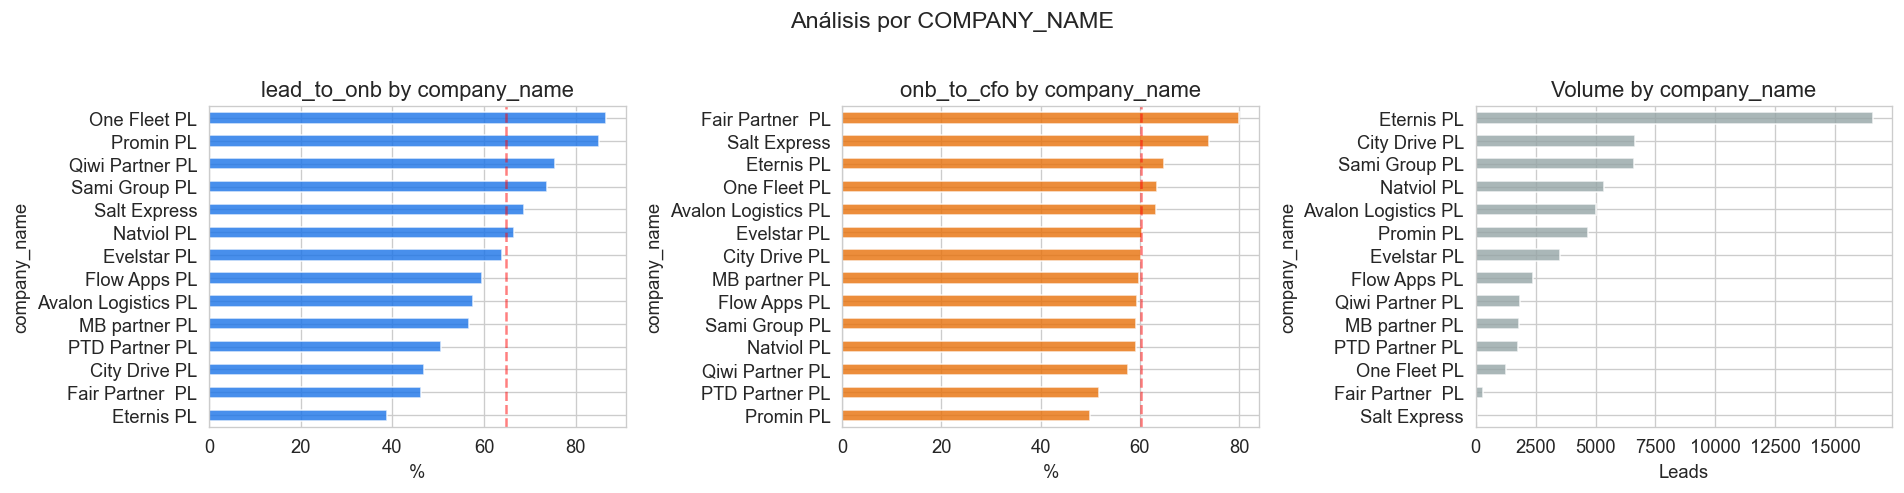


>> REGISTERED_VIA_WEB
       total_leads  onboarded    cfo  lead_to_onb  onb_to_cfo
1.0          57823      33112  19780         57.3        59.7
TOTAL        57823      33112  19780         57.3        59.7


In [ ]:
# 9.3 Drivers de conversión por workflow (source, company, registered_via_web)
for wf_name, cfg in WORKFLOWS.items():
    wf_df = df[df['workflow_name'] == wf_name]
    
    print(f"\n{'#'*80}")
    print(f"## {cfg['label']}")
    print(f"{'#'*80}")
    
    for var in ['source', 'company_name', 'registered_via_web']:
        analyze_variable(wf_df, var)


>> TIEMPOS — Other leads PL (con asignación 3PL)

Tiempos medianos por fase (días):
                      Leads válidos   Media  Mediana
Pending 3PL                 91792.0   0.489    0.001
Document Collection         61662.0   1.157    0.006
Document Review             47391.0   1.365    0.096
Waiting List                45468.0   4.523    0.000
Equipment Collection        40370.0   2.737    0.787
Lead to ONB                 38964.0  13.822    5.886

CFO vs No CFO:
                      No CFO  Sí CFO  Diferencia  N datos
Pending 3PL            0.001   0.001       0.000    91792
Document Collection    0.006   0.006       0.000    61662
Document Review        0.093   0.099      -0.006    47391
Waiting List           0.001   0.000       0.001    45468
Equipment Collection   0.828   0.757       0.072    40370
Lead to ONB            8.946   4.122       4.824    38964


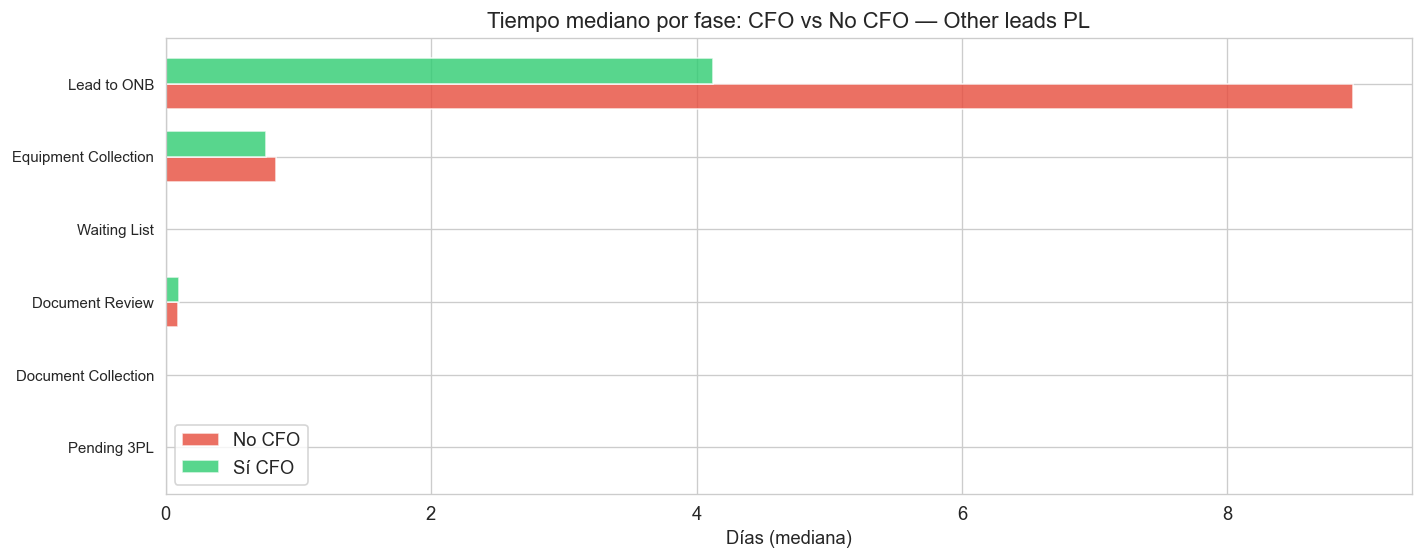


>> TIEMPOS — 3PL already assigned leads PL (sin asignación 3PL)

Tiempos medianos por fase (días):
                      Leads válidos  Media  Mediana
Document Collection         44549.0  0.767    0.003
Document Review             37050.0  1.098    0.062
Waiting List                36457.0  2.781    0.000
Equipment Collection        34497.0  2.037    0.334
Lead to ONB                 33132.0  8.371    2.654

CFO vs No CFO:
                      No CFO  Sí CFO  Diferencia  N datos
Document Collection    0.003   0.003       0.000    44549
Document Review        0.068   0.057       0.011    37050
Waiting List           0.000   0.000       0.000    36457
Equipment Collection   0.495   0.289       0.206    34497
Lead to ONB            3.968   1.839       2.129    33132


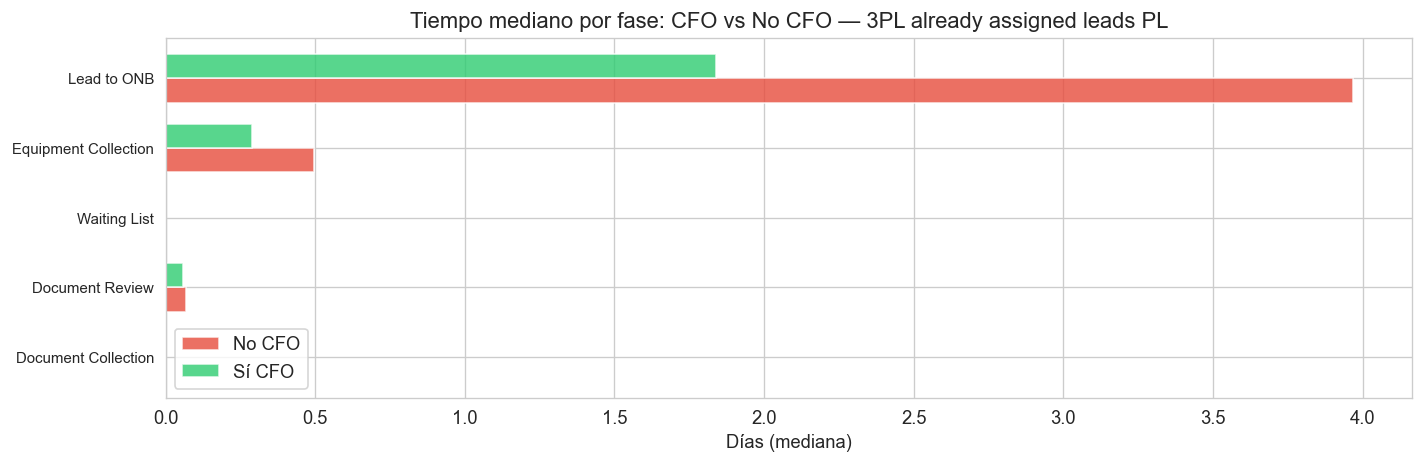

In [ ]:
# 9.4 Tiempos medianos y CFO vs No CFO por workflow
for wf_name, cfg in WORKFLOWS.items():
    wf_df = df[df['workflow_name'] == wf_name]
    wf_time_cols = cfg['time_cols']
    
    print(f"\n{'='*80}")
    print(f">> TIEMPOS — {cfg['label']}")
    print(f"{'='*80}")
    
    # Tiempos medianos globales
    wf_time_stats = wf_df[wf_time_cols].describe().T[['count', 'mean', '50%']]
    wf_time_stats.columns = ['Leads válidos', 'Media', 'Mediana']
    print("\nTiempos medianos por fase (días):")
    print(wf_time_stats.round(3))
    
    # CFO vs No CFO
    wf_tiempos_cfo = wf_df.groupby('is_cfo')[wf_time_cols].median().T
    wf_tiempos_cfo.columns = ['No CFO', 'Sí CFO']
    wf_tiempos_cfo['Diferencia'] = wf_tiempos_cfo['No CFO'] - wf_tiempos_cfo['Sí CFO']
    wf_tiempos_cfo['N datos'] = wf_df[wf_time_cols].notna().sum()
    print(f"\nCFO vs No CFO:")
    print(wf_tiempos_cfo.round(3))
    
    # Gráfico CFO vs No CFO
    fig, ax = plt.subplots(figsize=(12, max(4, len(wf_time_cols) * 0.8)))
    plot_data = wf_tiempos_cfo[['No CFO', 'Sí CFO']].dropna()
    x = range(len(plot_data))
    w = 0.35
    ax.barh([i - w/2 for i in x], plot_data['No CFO'], w, label='No CFO', color=COLORS['danger'], alpha=0.8)
    ax.barh([i + w/2 for i in x], plot_data['Sí CFO'], w, label='Sí CFO', color=COLORS['success'], alpha=0.8)
    ax.set_yticks(list(x))
    ax.set_yticklabels(plot_data.index, fontsize=9)
    ax.set_xlabel('Días (mediana)')
    ax.set_title(f'Tiempo mediano por fase: CFO vs No CFO — {wf_name}')
    ax.legend()
    plt.tight_layout()
    plt.show()


>> TIEMPOS POR SOURCE — Other leads PL (con asignación 3PL)

Pending 3PL:
source
3PL             0.001
JOB PLATFORM    0.001
ORGANIC         0.001
PERF MKT        0.001
RIDER WEB       0.001
REFERRAL        0.001
OFFLINE         0.001

Document Collection:
source
3PL             0.004
PERF MKT        0.004
REFERRAL        0.004
ORGANIC         0.006
RIDER WEB       0.006
JOB PLATFORM    0.010
OFFLINE         0.015

Document Review:
source
OFFLINE         0.004
JOB PLATFORM    0.061
REFERRAL        0.071
ORGANIC         0.096
PERF MKT        0.114
RIDER WEB       0.217
3PL             0.478

Waiting List:
source
3PL             0.000
JOB PLATFORM    0.000
ORGANIC         0.000
PERF MKT        0.000
RIDER WEB       0.000
REFERRAL        0.089
OFFLINE         1.642

Equipment Collection:
source
3PL             0.620
JOB PLATFORM    0.708
PERF MKT        0.740
RIDER WEB       0.792
ORGANIC         0.806
REFERRAL        0.815
OFFLINE         2.686

Lead to ONB:
source
3PL              1.85

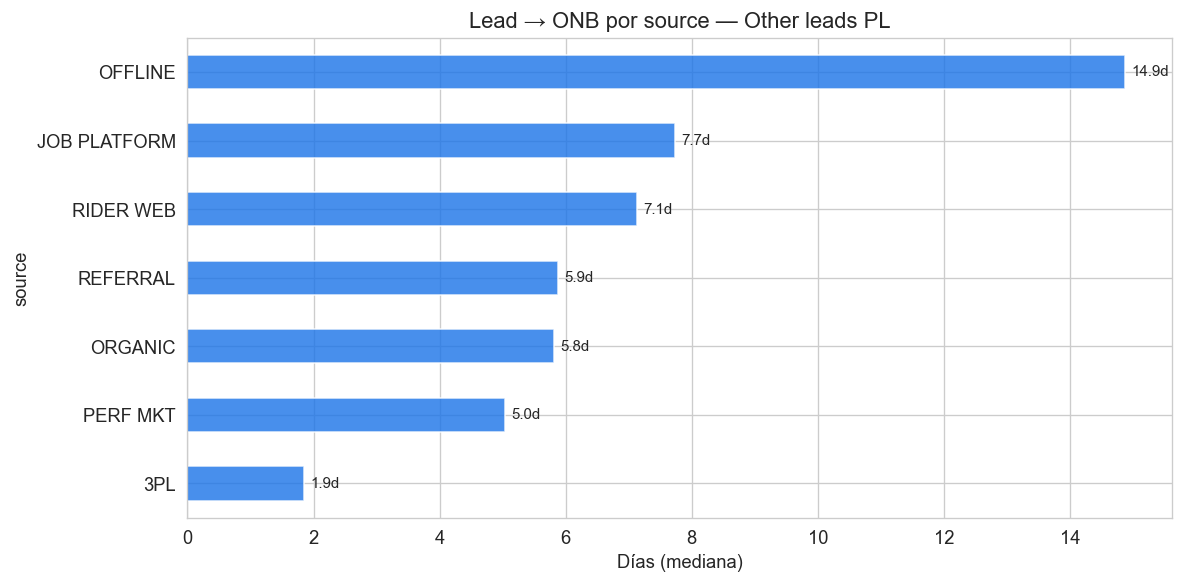


>> TIEMPOS POR SOURCE — 3PL already assigned leads PL (sin asignación 3PL)

Document Collection:
source
3PL         0.003
ORGANIC     0.003
REFERRAL    0.003
PERF MKT    5.548

Document Review:
source
3PL         0.060
REFERRAL    0.064
ORGANIC     0.119
PERF MKT    3.650

Waiting List:
source
3PL         0.0
ORGANIC     0.0
PERF MKT    0.0
REFERRAL    0.0

Equipment Collection:
source
PERF MKT    0.220
REFERRAL    0.256
3PL         0.375
ORGANIC     0.599

Lead to ONB:
source
REFERRAL    1.899
ORGANIC     2.029
3PL         2.857
PERF MKT    9.817


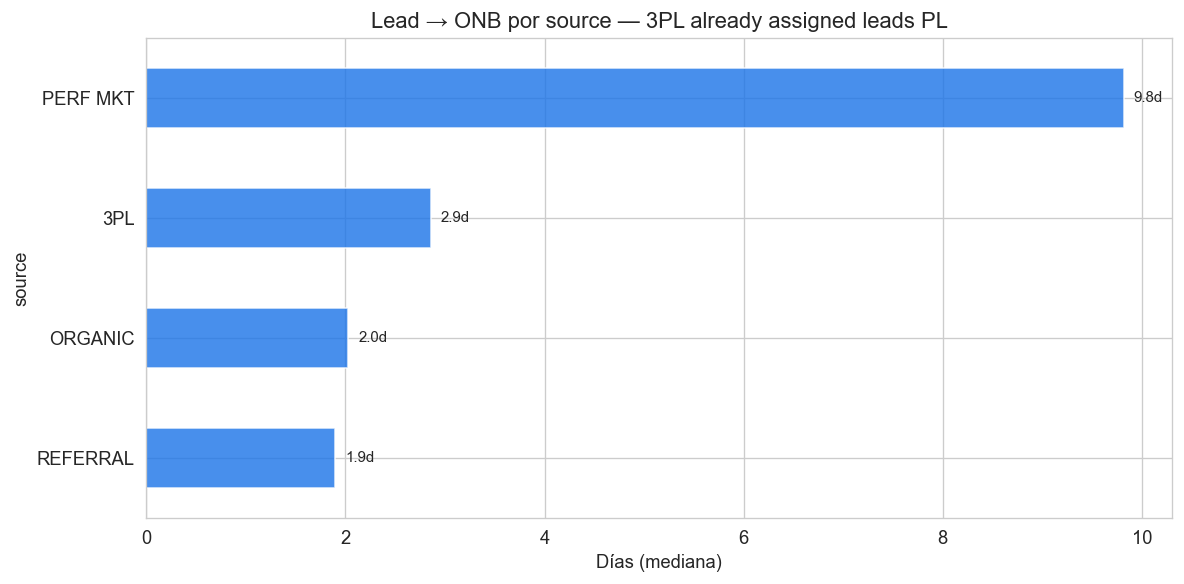

In [ ]:
# 9.5 Tiempos por source por workflow
for wf_name, cfg in WORKFLOWS.items():
    wf_df = df[df['workflow_name'] == wf_name]
    
    print(f"\n{'='*80}")
    print(f">> TIEMPOS POR SOURCE — {cfg['label']}")
    print(f"{'='*80}")
    
    for col in cfg['time_cols']:
        if wf_df[col].notna().sum() > 50:
            t_source = wf_df.groupby('source')[col].median().sort_values()
            if t_source.notna().sum() > 1:
                print(f"\n{col}:")
                print(t_source.round(3).to_string())
    
    # Gráfico Lead to ONB por source
    fig, ax = plt.subplots(figsize=(10, 5))
    lt_source = wf_df.groupby('source')['Lead to ONB'].median().dropna().sort_values()
    lt_source.plot.barh(ax=ax, color=COLORS['primary'], alpha=0.8, edgecolor='white')
    ax.set_xlabel('Días (mediana)')
    ax.set_title(f'Lead → ONB por source — {wf_name}')
    for i, v in enumerate(lt_source.values):
        if not np.isnan(v):
            ax.text(v + 0.1, i, f'{v:.1f}d', va='center', fontsize=9)
    plt.tight_layout()
    plt.show()

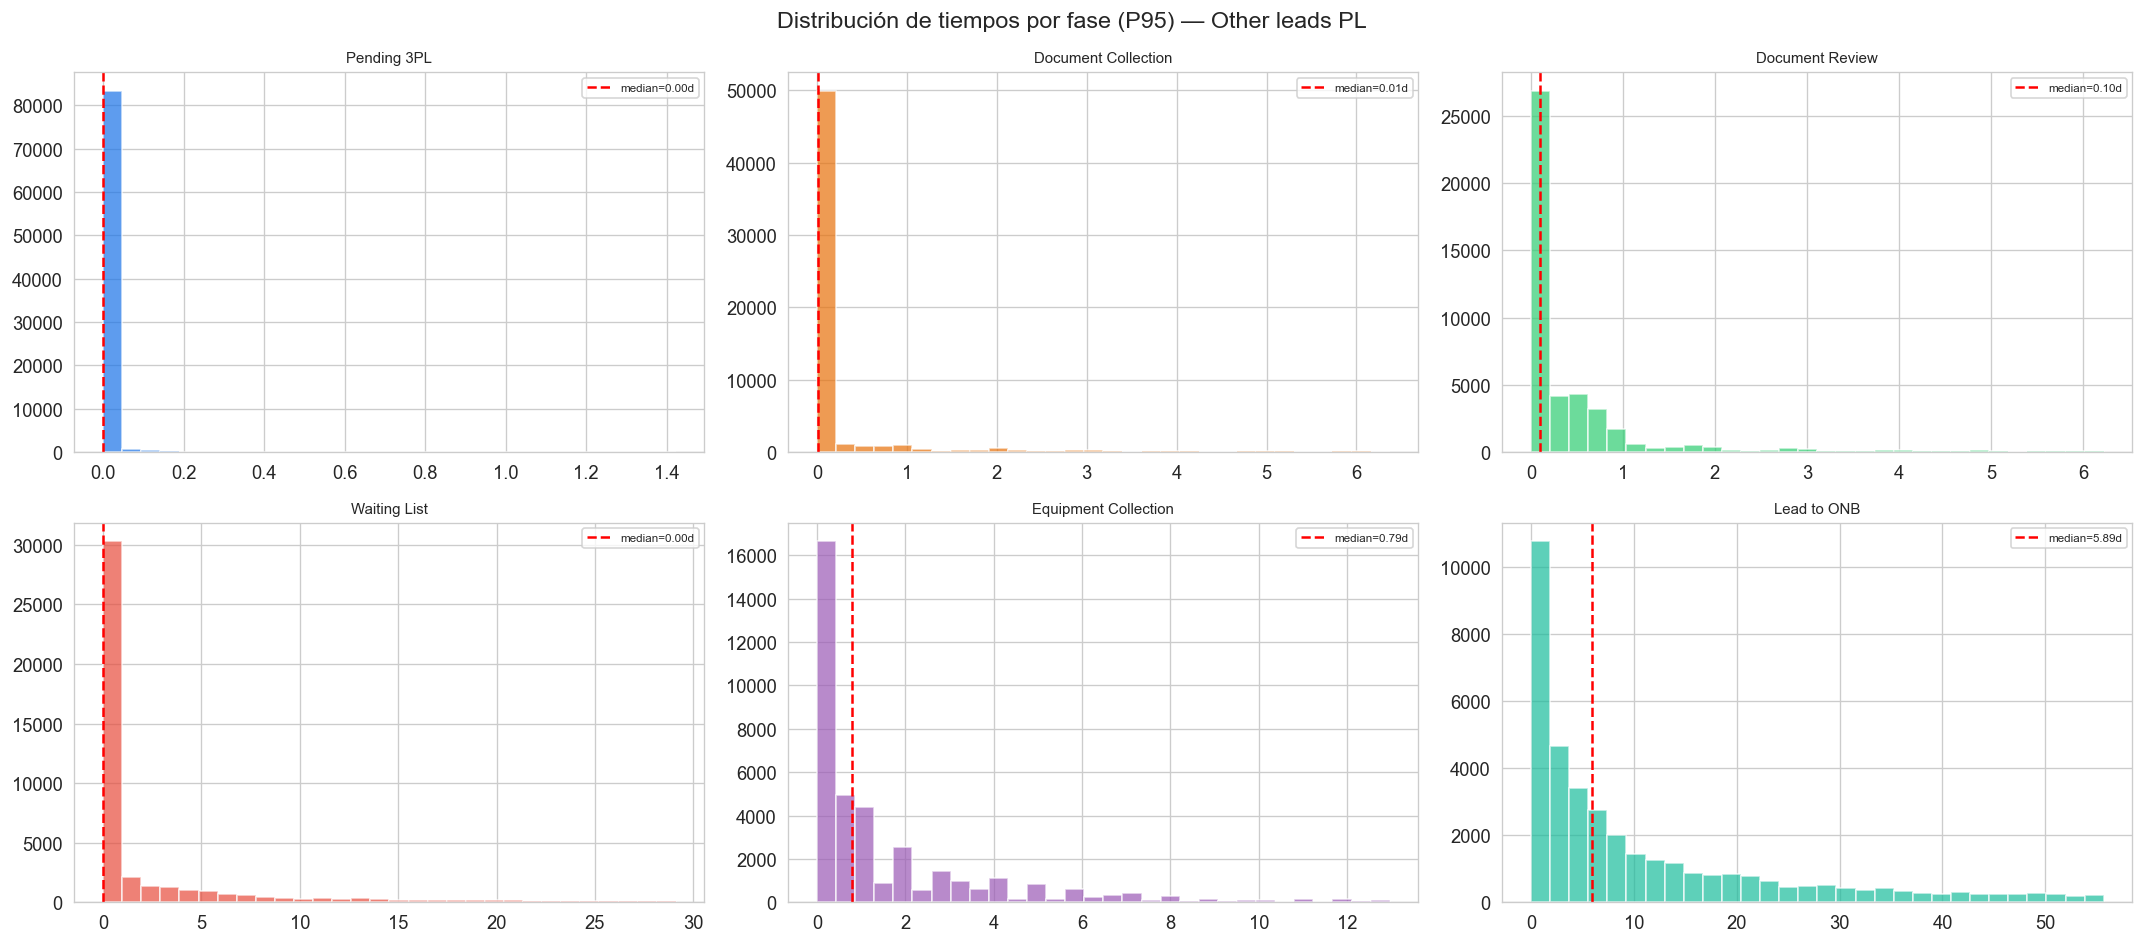

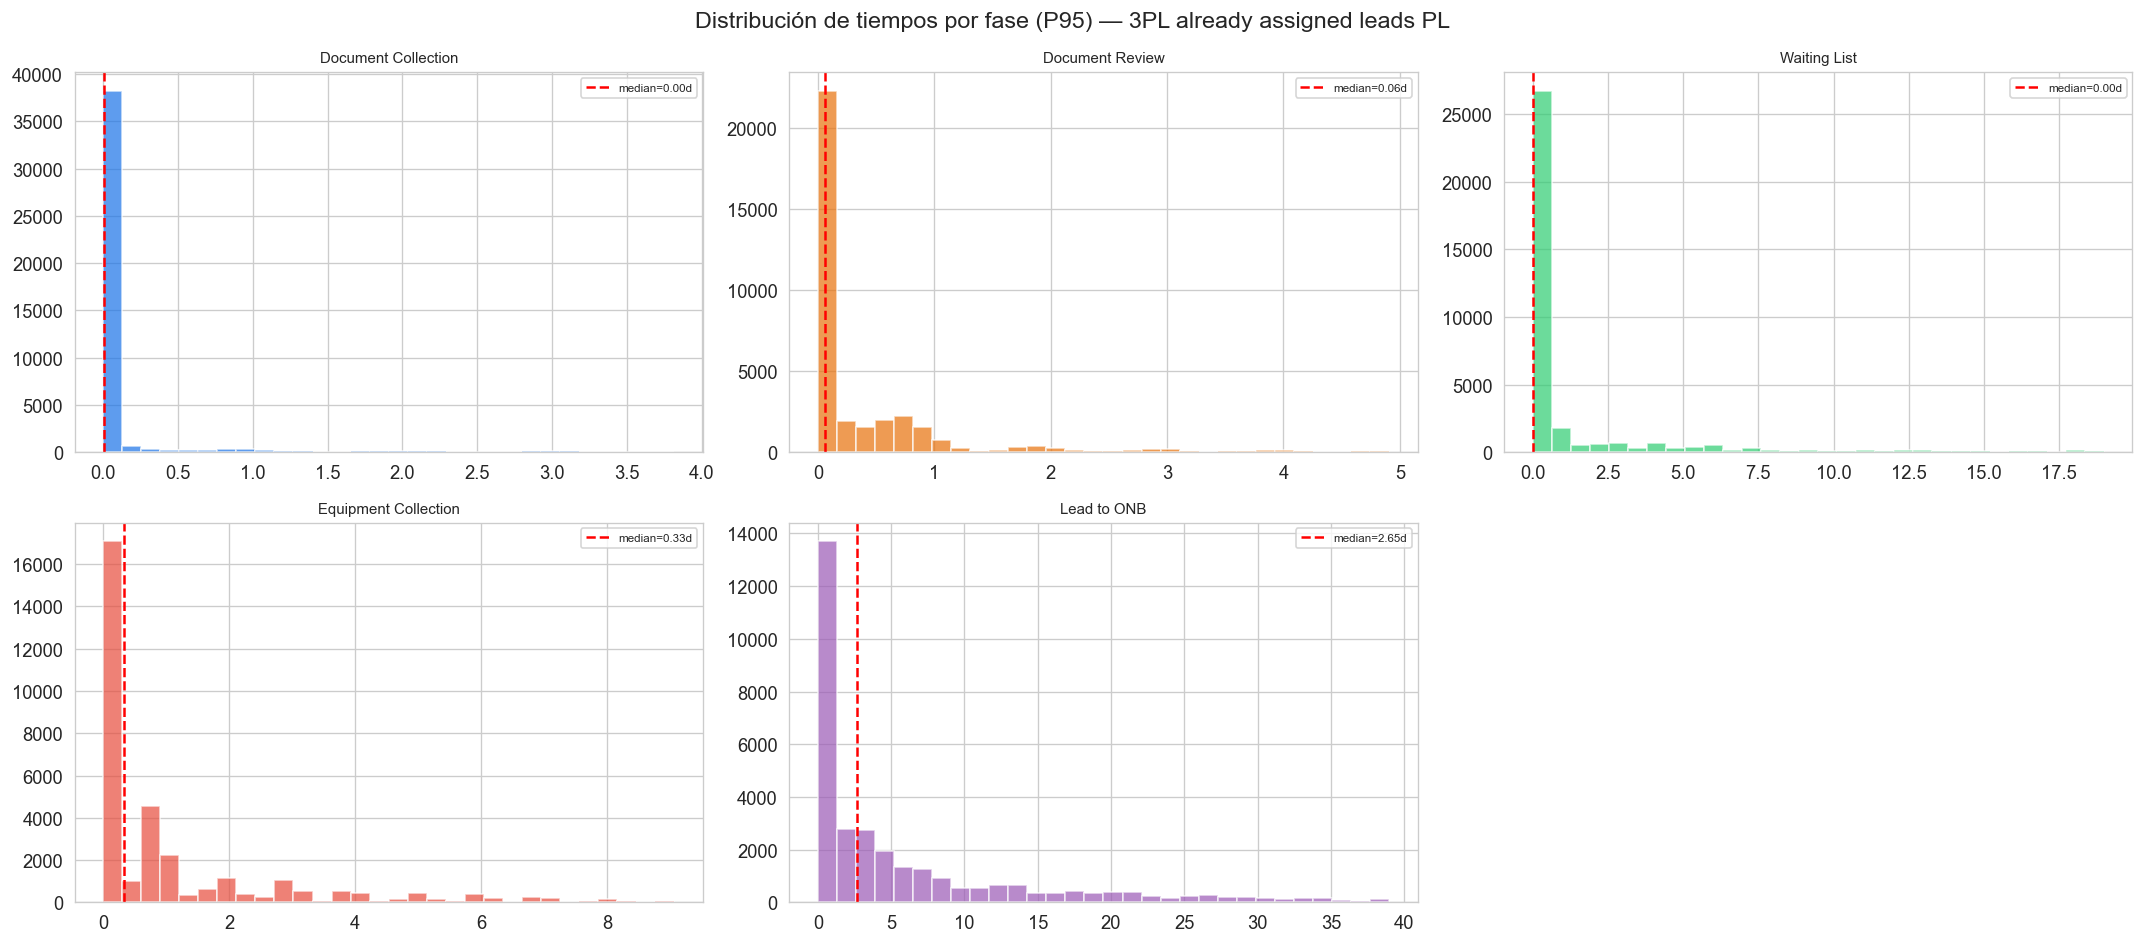

In [ ]:
# 9.6 Distribución de tiempos por fase y workflow (histogramas)
for wf_name, cfg in WORKFLOWS.items():
    wf_df = df[df['workflow_name'] == wf_name]
    wf_time_cols = cfg['time_cols']
    
    n_cols_wf = len(wf_time_cols)
    n_rows_wf = (n_cols_wf + 2) // 3
    fig, axes = plt.subplots(n_rows_wf, 3, figsize=(18, 4 * n_rows_wf))
    axes = axes.flatten()
    
    for i, col in enumerate(wf_time_cols):
        data = wf_df[col].dropna()
        if len(data) > 10:
            upper = data.quantile(0.95)
            data_clipped = data[data <= upper]
            axes[i].hist(data_clipped, bins=30, color=COLORS['palette'][i % len(COLORS['palette'])],
                         alpha=0.7, edgecolor='white')
            axes[i].axvline(data.median(), color='red', linestyle='--', linewidth=1.5,
                            label=f'median={data.median():.2f}d')
            axes[i].set_title(col, fontsize=9)
            axes[i].legend(fontsize=7)
        else:
            axes[i].text(0.5, 0.5, f'{col}\n(N={len(data)})', ha='center', va='center',
                         transform=axes[i].transAxes)
    
    for j in range(len(wf_time_cols), len(axes)):
        axes[j].set_visible(False)
    
    plt.suptitle(f'Distribución de tiempos por fase (P95) — {wf_name}', fontsize=14)
    plt.tight_layout()
    plt.show()


>> CIUDADES — Other leads PL (con asignación 3PL)
           leads  onboarded   cfo  median_time  lead_to_onb  onb_to_cfo
city_code                                                              
WAW        17217       6928  4164          2.9         40.2        60.1
KRA         6345       2321  1399          3.8         36.6        60.3
WRO         5639       1792   990          7.2         31.8        55.2
LOD         5088       1808  1173          5.1         35.5        64.9
POZ         4879       1619   876          5.8         33.2        54.1
GDN         4549       1921  1121          2.7         42.2        58.4
KTW         2951        967   484          6.0         32.8        50.1
SZZ         2824       1044   585          3.8         37.0        56.0
BZG         2313        804   425          6.8         34.8        52.9
SZY         1894        715   417          4.4         37.8        58.3
QYY         1726        622   360          6.1         36.0        57.9
RZE         1

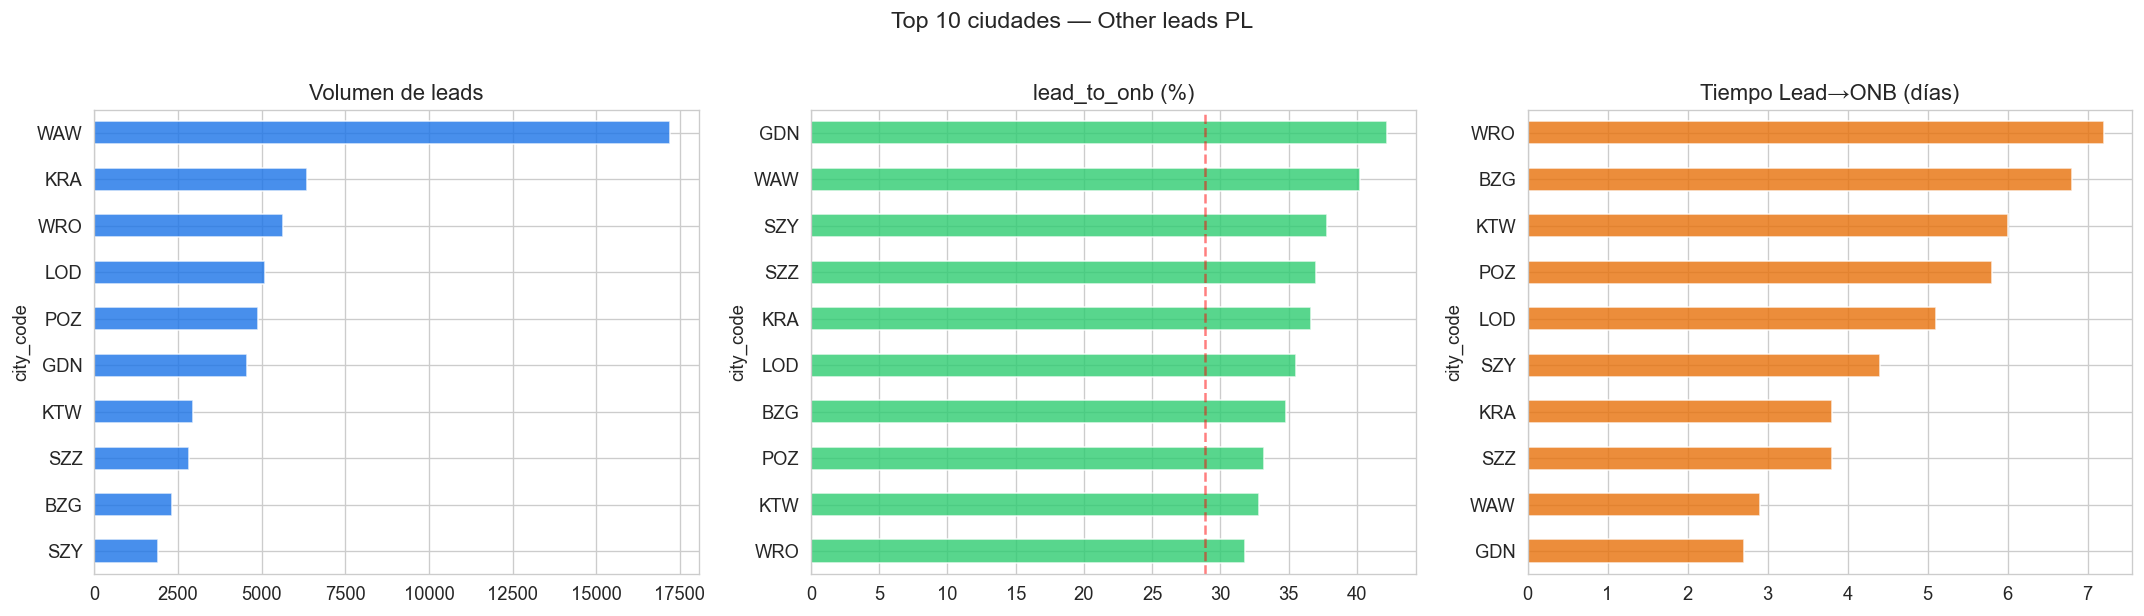


>> CIUDADES — 3PL already assigned leads PL (sin asignación 3PL)
           leads  onboarded   cfo  median_time  lead_to_onb  onb_to_cfo
city_code                                                              
WAW        15048       9418  5213          1.1         62.6        55.4
KRA         6190       3389  2353          2.0         54.7        69.4
POZ         4750       2761  1644          2.9         58.1        59.5
WRO         4533       2519  1400          4.9         55.6        55.6
LOD         4225       2549  1772          2.0         60.3        69.5
GDN         3628       2698  1717          1.0         74.4        63.6
KTW         1913        827   475          4.8         43.2        57.4
SZZ         1212        804   511          1.5         66.3        63.6
BZG         1049        653   390          3.0         62.2        59.7
QLU          982        545   320          5.9         55.5        58.7
TUN          941        351   174          4.8         37.3        49.

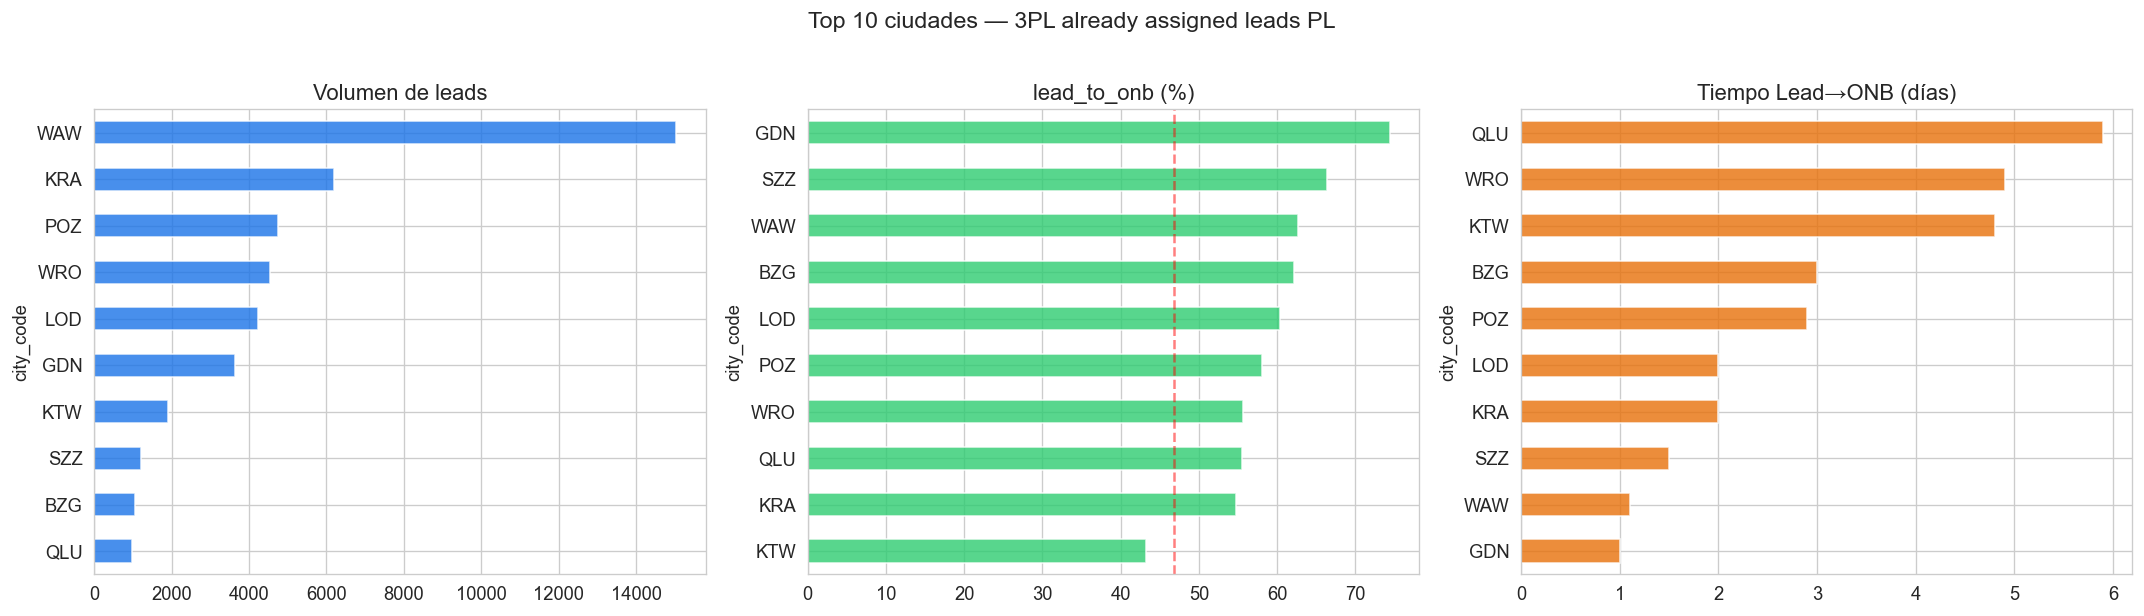

In [ ]:
# 9.7 Ciudades por workflow
for wf_name, cfg in WORKFLOWS.items():
    wf_df = df[df['workflow_name'] == wf_name]
    
    wf_city = wf_df.groupby('city_code').agg(
        leads=('applicant_id', 'count'),
        onboarded=('was_hired', 'sum'),
        cfo=('is_cfo', 'sum'),
        median_time=('Lead to ONB', 'median')
    ).sort_values('leads', ascending=False)
    
    wf_city['lead_to_onb'] = (wf_city['onboarded'] / wf_city['leads'] * 100).round(1)
    wf_city['onb_to_cfo'] = (wf_city['cfo'] / wf_city['onboarded'].replace(0, np.nan) * 100).round(1)
    wf_city['median_time'] = wf_city['median_time'].round(1)
    
    print(f"\n{'='*80}")
    print(f">> CIUDADES — {cfg['label']}")
    print(f"{'='*80}")
    print(wf_city.head(15).to_string())
    
    # Top 10
    top = wf_city.head(10)
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    top['leads'].sort_values().plot.barh(ax=axes[0], color=COLORS['primary'], alpha=0.8)
    axes[0].set_title('Volumen de leads')
    
    top['lead_to_onb'].sort_values().plot.barh(ax=axes[1], color=COLORS['success'], alpha=0.8)
    axes[1].set_title('lead_to_onb (%)')
    axes[1].axvline(wf_city['lead_to_onb'].mean(), color='red', linestyle='--', alpha=0.5)
    
    top['median_time'].sort_values().plot.barh(ax=axes[2], color=COLORS['secondary'], alpha=0.8)
    axes[2].set_title('Tiempo Lead→ONB (días)')
    
    plt.suptitle(f'Top 10 ciudades — {wf_name}', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

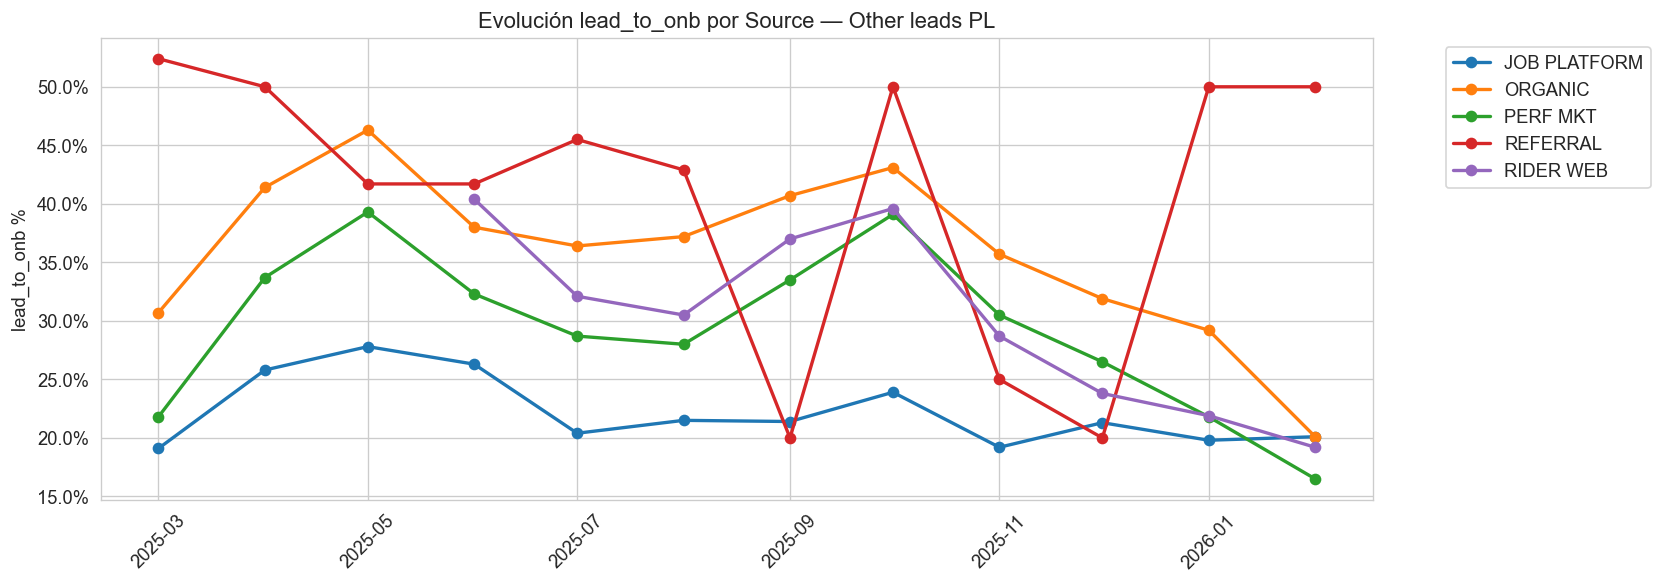

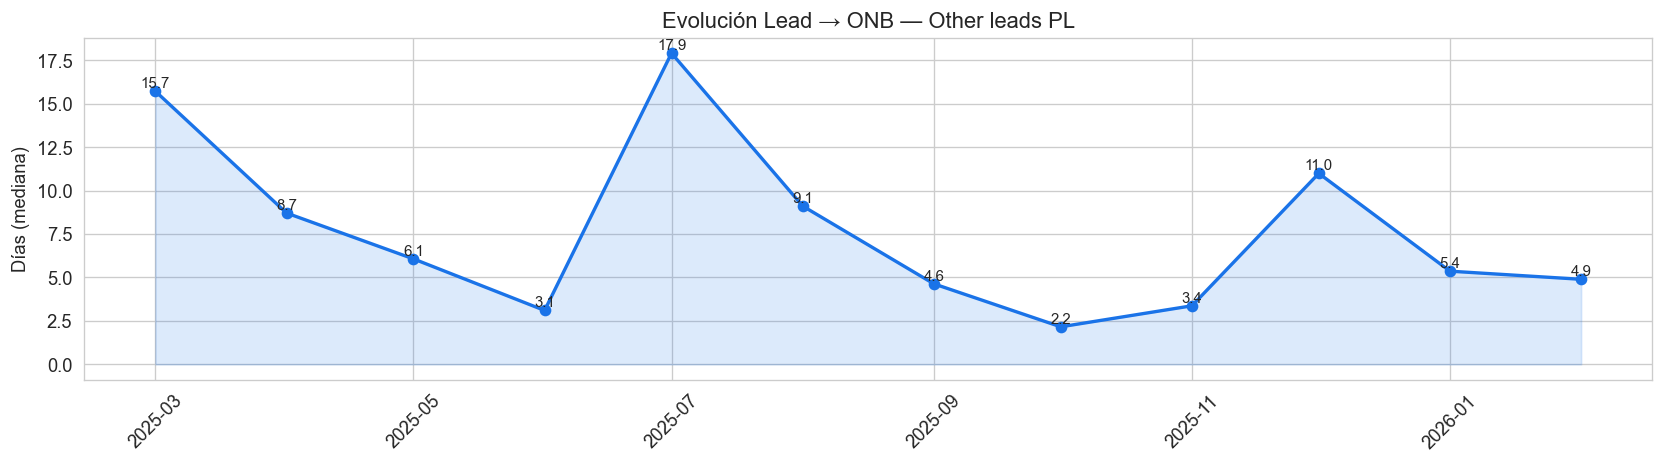

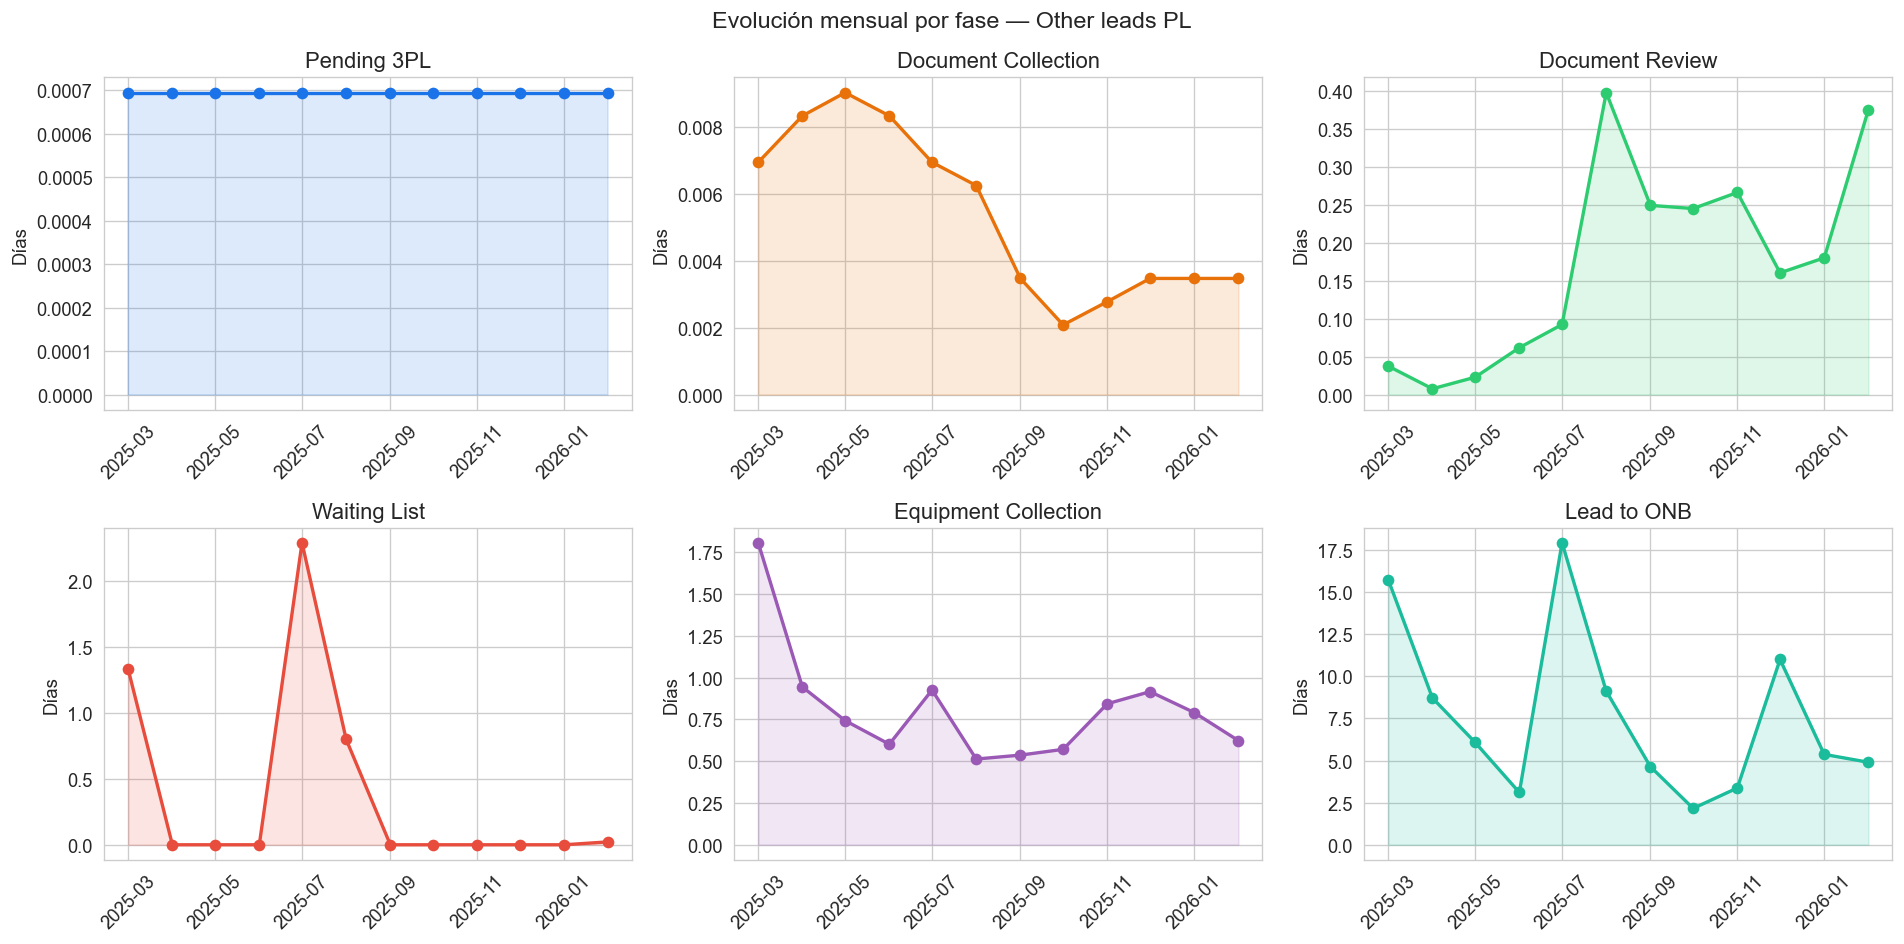

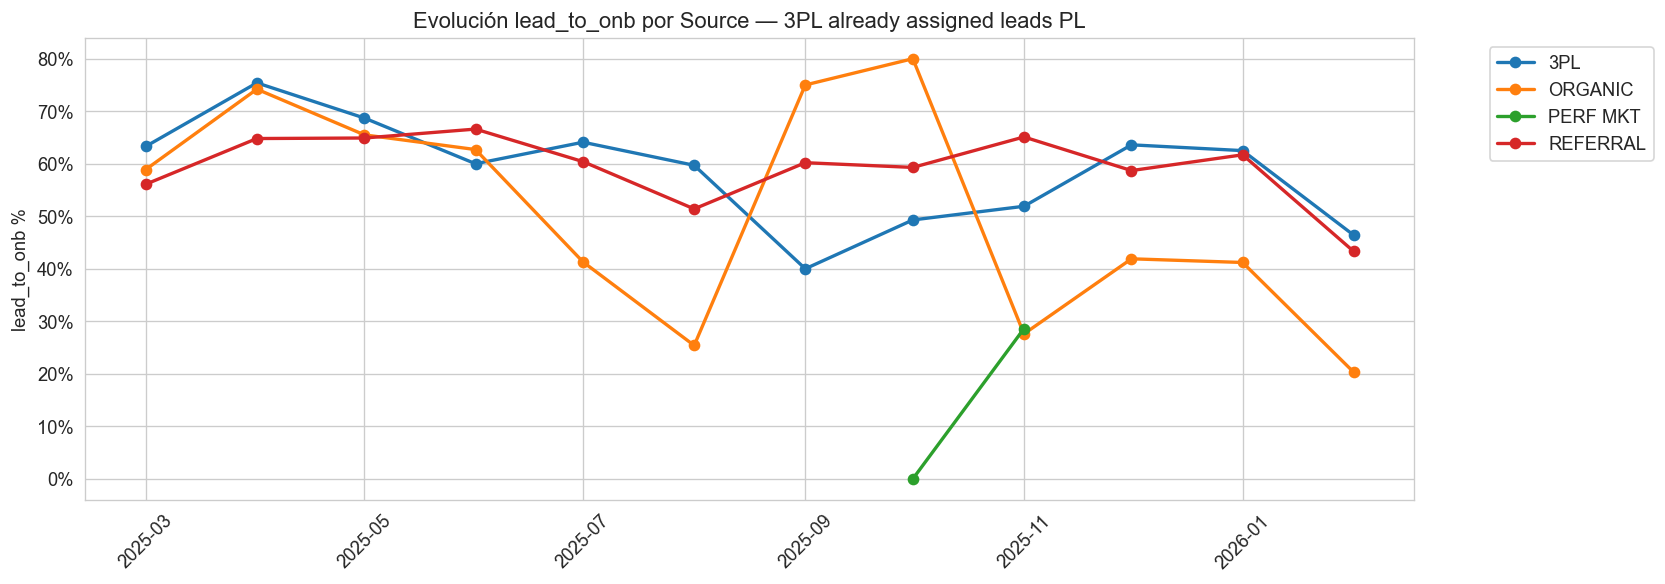

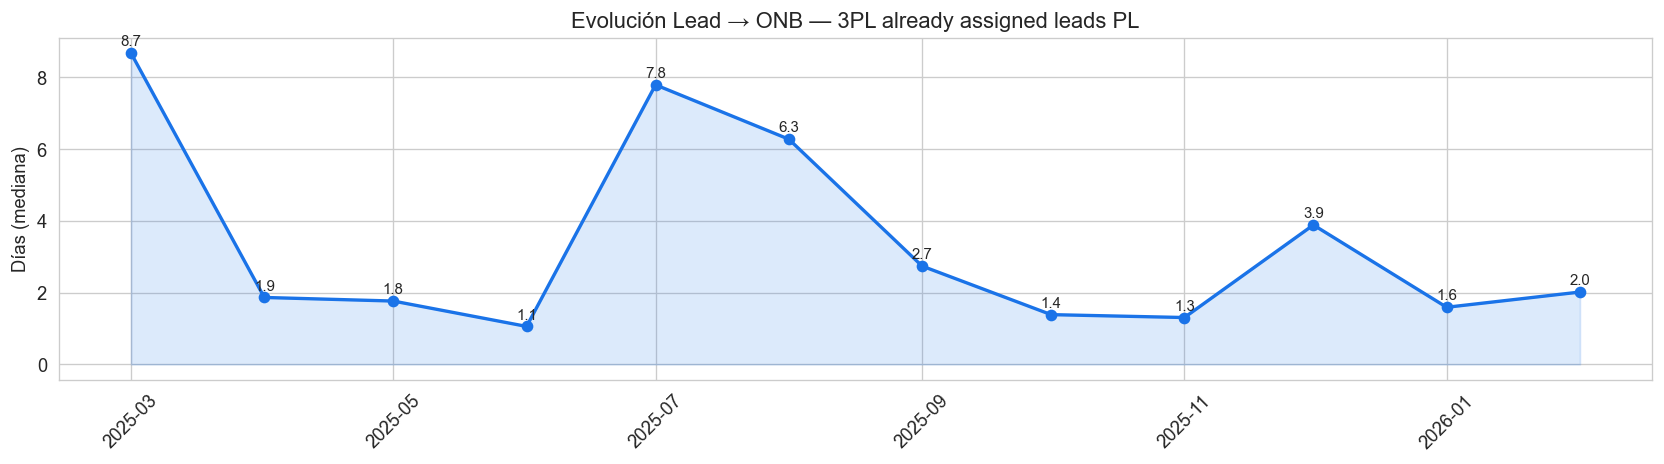

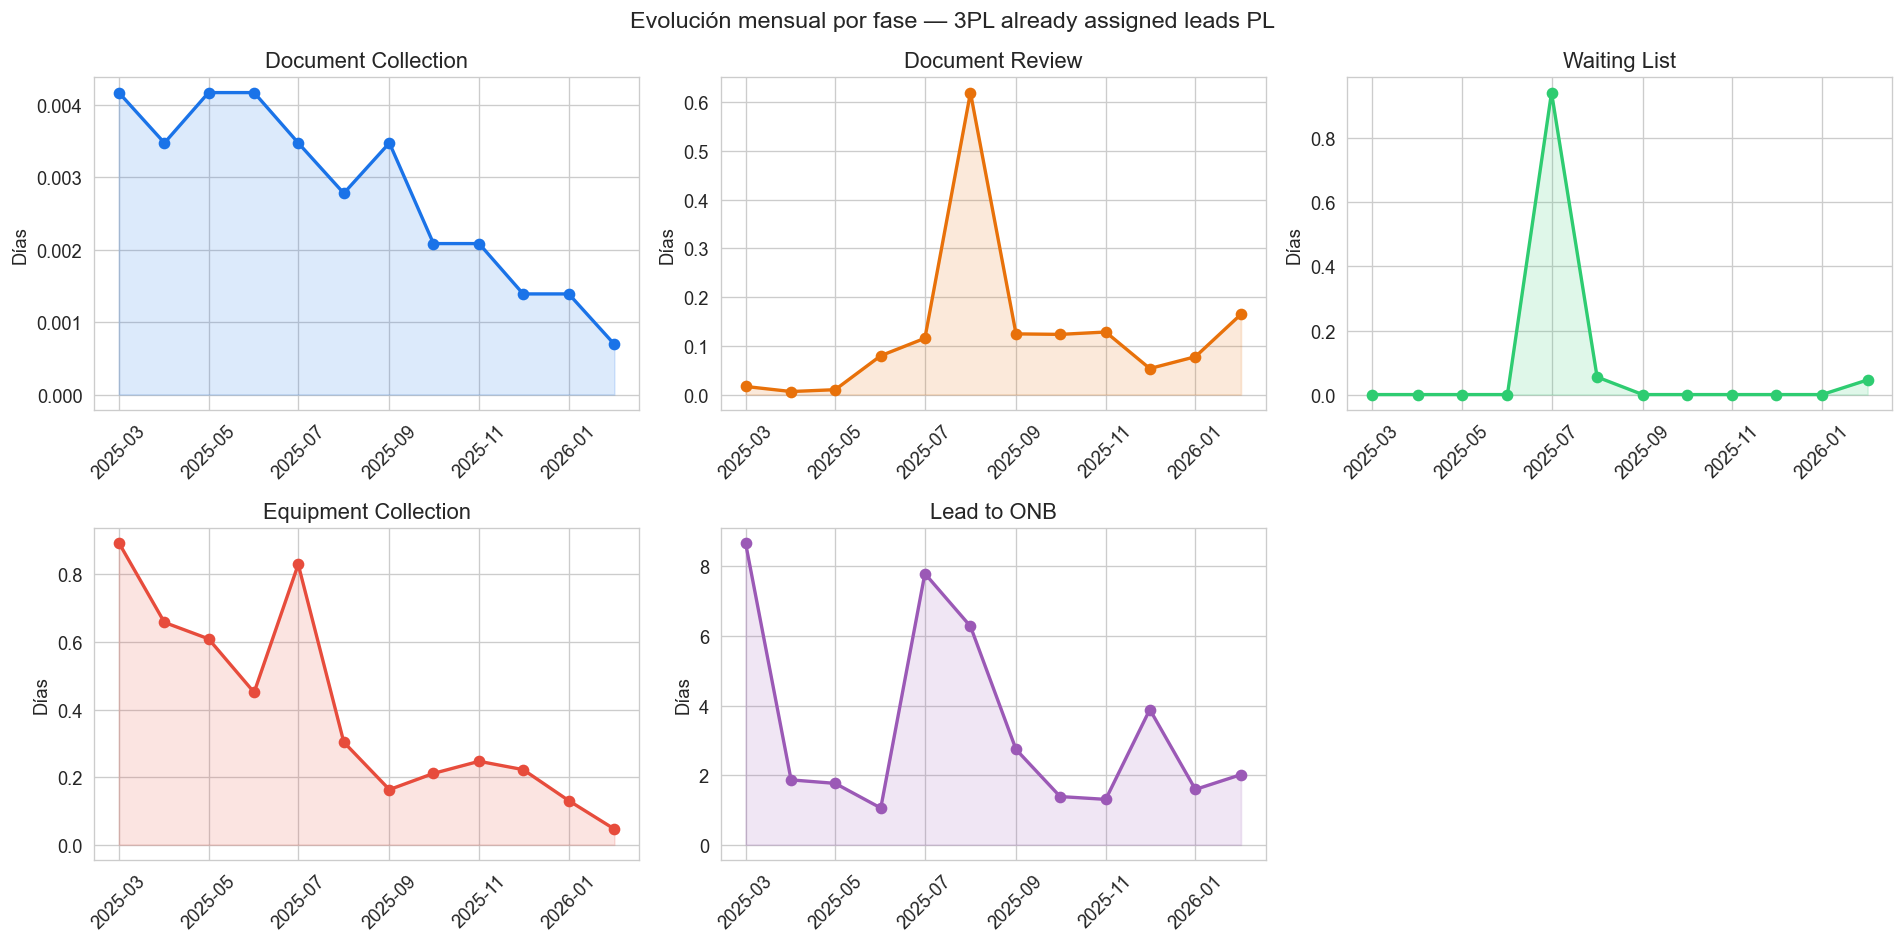

In [ ]:
# 9.8 Evolución temporal por workflow
for wf_name, cfg in WORKFLOWS.items():
    wf_df = df[df['workflow_name'] == wf_name]
    wf_time_cols = cfg['time_cols']
    
    # Evolución lead_to_onb por source
    wf_sources_top = wf_df['source'].value_counts().head(5).index.tolist()
    wf_top_src = wf_df[wf_df['source'].isin(wf_sources_top)]
    wf_pivot = wf_top_src.groupby(['month', 'source'])['was_hired'].mean().unstack()
    wf_pivot = (wf_pivot * 100).round(1)
    
    fig, ax = plt.subplots(figsize=(14, 5))
    for col in wf_pivot.columns:
        ax.plot(wf_pivot.index, wf_pivot[col], marker='o', label=col, linewidth=2)
    ax.set_ylabel('lead_to_onb %')
    ax.set_title(f'Evolución lead_to_onb por Source — {wf_name}')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.tick_params(axis='x', rotation=45)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    plt.tight_layout()
    plt.show()
    
    # Evolución Lead to ONB
    wf_monthly_time = wf_df.groupby('month')['Lead to ONB'].median()
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(wf_monthly_time.index, wf_monthly_time.values, marker='o', color=COLORS['primary'], linewidth=2)
    ax.fill_between(wf_monthly_time.index, wf_monthly_time.values, alpha=0.15, color=COLORS['primary'])
    ax.set_ylabel('Días (mediana)')
    ax.set_title(f'Evolución Lead → ONB — {wf_name}')
    ax.tick_params(axis='x', rotation=45)
    for date, val in wf_monthly_time.items():
        if not np.isnan(val):
            ax.text(date, val + 0.2, f'{val:.1f}', ha='center', fontsize=9)
    plt.tight_layout()
    plt.show()
    
    # Evolución por fase
    n_cols_wf = len(wf_time_cols)
    n_rows_wf = (n_cols_wf + 2) // 3
    fig, axes = plt.subplots(n_rows_wf, 3, figsize=(16, 4 * n_rows_wf))
    axes = axes.flatten()
    
    for i, phase in enumerate(wf_time_cols):
        mp = wf_df.groupby('month')[phase].median()
        axes[i].plot(mp.index, mp.values, marker='o',
                     color=COLORS['palette'][i % len(COLORS['palette'])], linewidth=2)
        axes[i].fill_between(mp.index, mp.values, alpha=0.15,
                             color=COLORS['palette'][i % len(COLORS['palette'])])
        axes[i].set_title(phase)
        axes[i].set_ylabel('Días')
        axes[i].tick_params(axis='x', rotation=45)
    
    for j in range(len(wf_time_cols), len(axes)):
        axes[j].set_visible(False)
    
    plt.suptitle(f'Evolución mensual por fase — {wf_name}', fontsize=14)
    plt.tight_layout()
    plt.show()